# Import

In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

import joblib
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator

c:\Users\antoi\Code\unif\MA2\thesis\src\ML\utils\Model_evaluator.py:467: SyntaxWarning: invalid escape sequence '\l'
  reverse_params = {'$\log(T_{\mathrm{eff}})$', '$\log(g)$'}
c:\Users\antoi\Code\unif\MA2\thesis\src\ML\utils\Model_evaluator.py:467: SyntaxWarning: invalid escape sequence '\l'
  reverse_params = {'$\log(T_{\mathrm{eff}})$', '$\log(g)$'}


In [3]:
pre_path = "../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_B/final_models/"
path_to_predictions = pre_path + "predictions/model_B/final_models/"
path_to_models = 'model/final_models/model_B/MIST/'
output_parameters = ['T_eff', 'log_g', 'radius']
categories_name = ["phase"]

In [4]:
override = False
use_preds = True
save = True
show = True

input_col_names = ['$\log(age)$', '$[\mathrm{Fe/H}]$', '$M_\odot$']
output_col_names = ['T_eff', 'log_g', 'radius']

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\o'
C:\Users\antoi\AppData\Local\Temp\ipykernel_12404\4260783930.py:6: SyntaxWarning: invalid escape sequence '\l'
  input_col_names = ['$\log(age)$', '$[\mathrm{Fe/H}]$', '$M_\odot$']
C:\Users\antoi\AppData\Local\Temp\ipykernel_12404\4260783930.py:6: SyntaxWarning: invalid escape sequence '\m'
  input_col_names = ['$\log(age)$', '$[\mathrm{Fe/H}]$', '$M_\odot$']
C:\Users\antoi\AppData\Local\Temp\ipykernel_12404\4260783930.py:6: SyntaxWarning: invalid escape sequence '\o'
  input_col_names = ['$\log(age)$', '$[\mathrm{Fe/H}]$', '$M_\odot$']


# Data preparation

In [5]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


In [6]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})

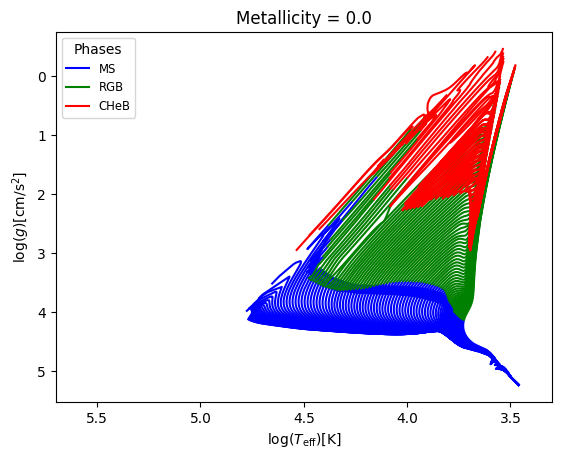

In [7]:
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [8]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'metallicity', 'star_mass'], 
                               y_cols=['log_Teff', 'log_g', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the log_Teff parameter : 3.344668191350628 - 5.378801600728572
Median value in train data for the log_Teff parameter: 3.976722754899366
Mean value in train data for the log_Teff parameter: 4.028639708216513

Range in train data for the log_g parameter : -1.0828963170617296 - 6.259434356871683
Median value in train data for the log_g parameter: 3.852761890388139
Mean value in train data for the log_g parameter: 3.508503471076473

Range in train data for the log_R parameter : -0.9974628481553472 - 3.129269620812593
Median value in train data for the log_R parameter: 0.7005259212303901
Mean value in train data for the log_R parameter: 0.7346615625058007

Testing set statistics:
Range in test data for the log_Teff parameter : 3.3447003632081813 - 5.3787504733463445
Median value in test data for the log_Teff parameter: 3.9741415586935043
Mean value in test data for the log_Teff parameter: 4.027301245585765

Range in test data for the log_g pa

In [9]:
X_train_quantile, X_ivs_quantile = Data_preparator.scale_data(X_train, X_ivs, "quantile")

print(X_train_quantile.shape, X_ivs_quantile.shape)

(472953, 3) (157652, 3)


# Getting the final evaluations

## Random forest

In [12]:
tag = "scale_quantile"


scale_quantile train data :
Evaluating predictions...
2.4648573848651267e-08
no negative values

T_eff results for the phase category with a value of 0.0
  value range :  3.3447003632081813 - 4.903113097363014
  RVE :  0.9831462094859403
  RMSE :  0.045941454069718037
  MAE :  0.010600423788293213
  MedAE :  0.001864508501055795
  CORR :  0.9915546122355356
  MAX_ER :  0.8235074753235909
  Percentiles : 
    75th percentile :  0.00453125118861597
    90th percentile :  0.01226885283651625
    95th percentile :  0.032649171437018884
    99th percentile :  0.22676544868883175

T_eff results for the phase category with a value of 2.0
  value range :  3.424526073183654 - 4.703420536058761
  RVE :  0.984967058275253
  RMSE :  0.03884223888370403
  MAE :  0.01858176421936817
  MedAE :  0.005421560129464709
  CORR :  0.9924948944453638
  MAX_ER :  0.5592448165228698
  Percentiles : 
    75th percentile :  0.015881916325109158
    90th percentile :  0.05793462124204738
    95th percentile :  

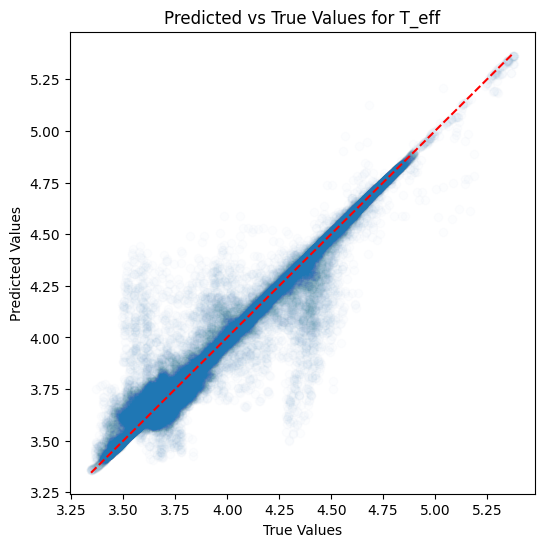

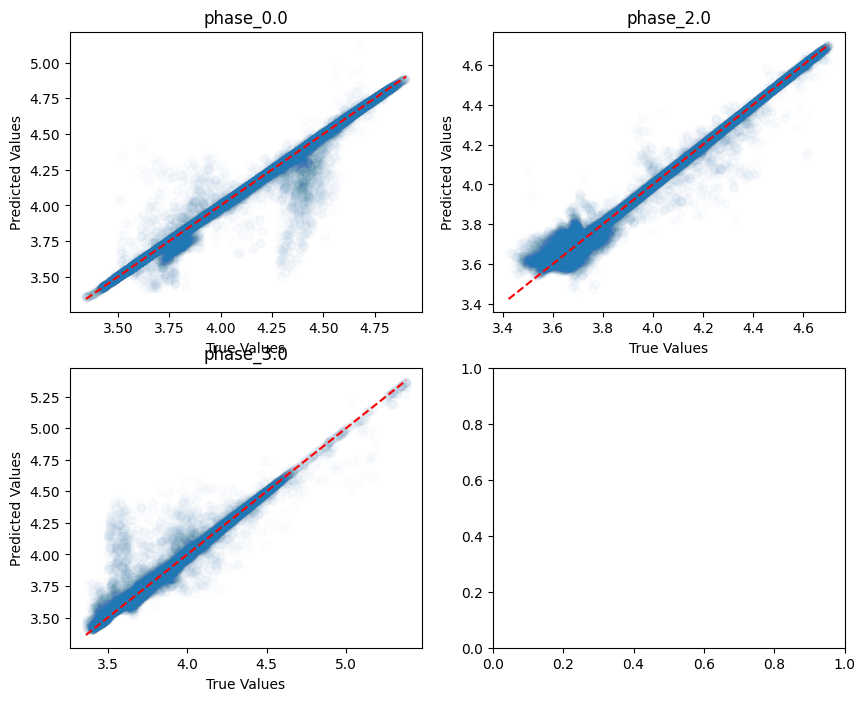

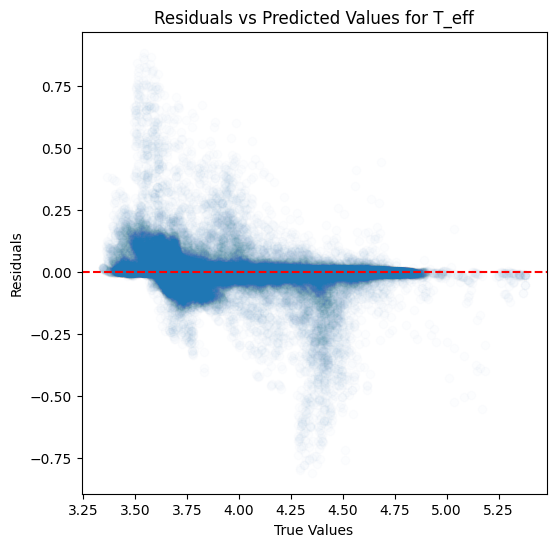

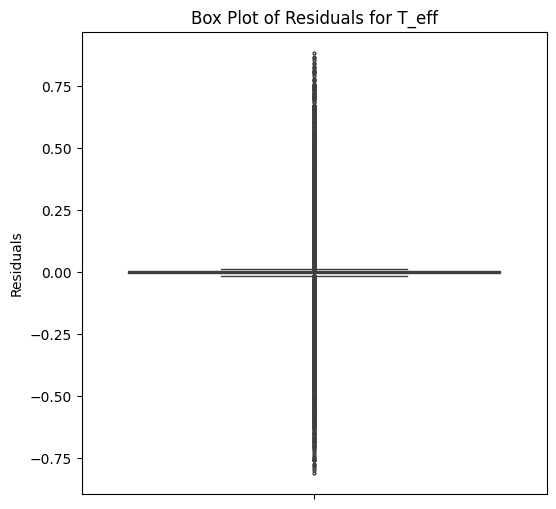

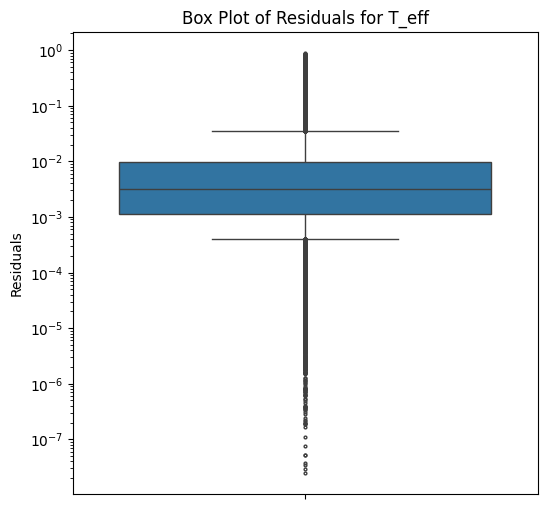

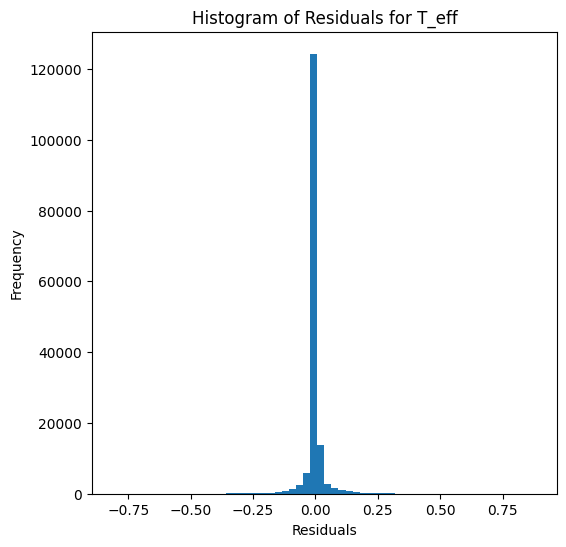

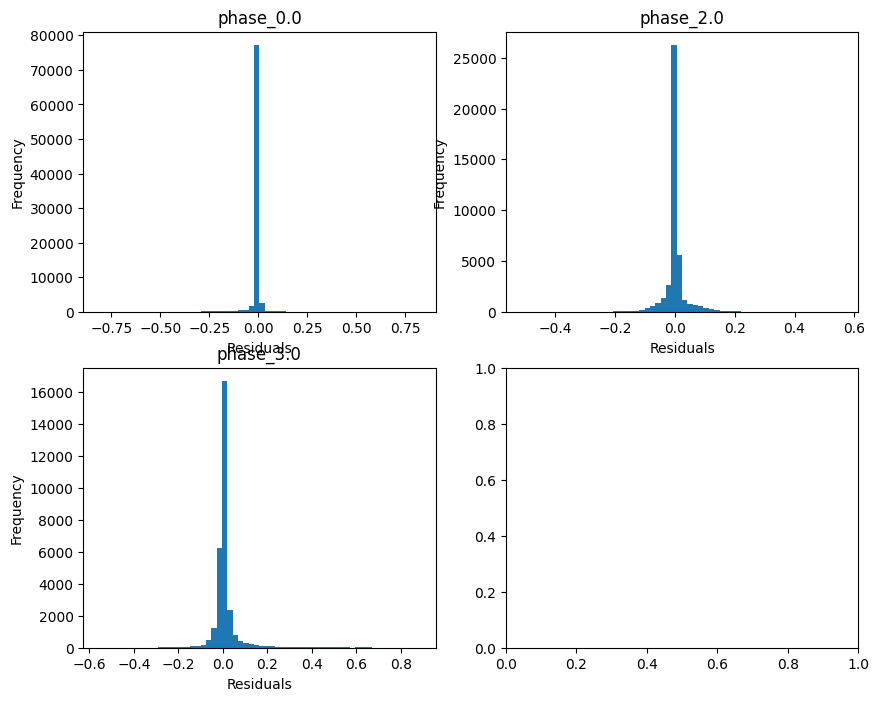

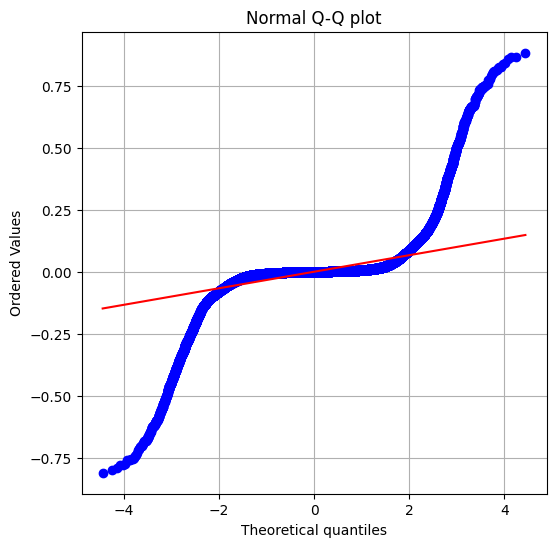

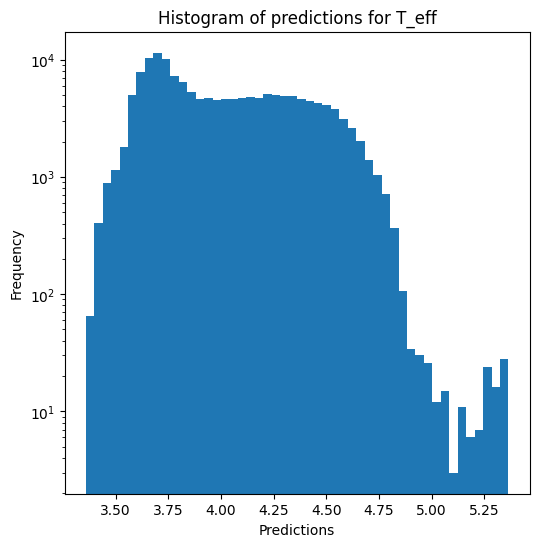

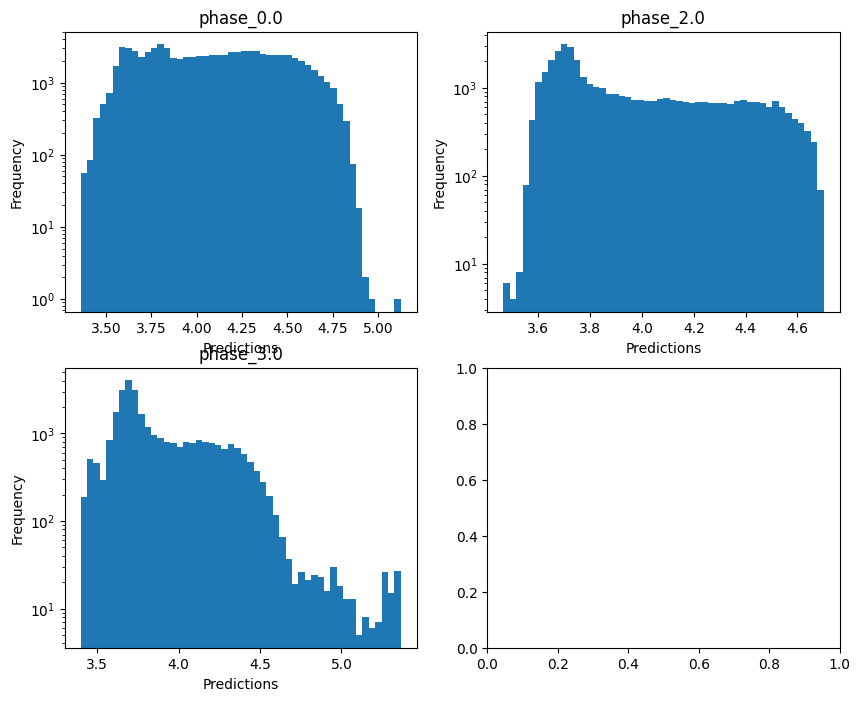

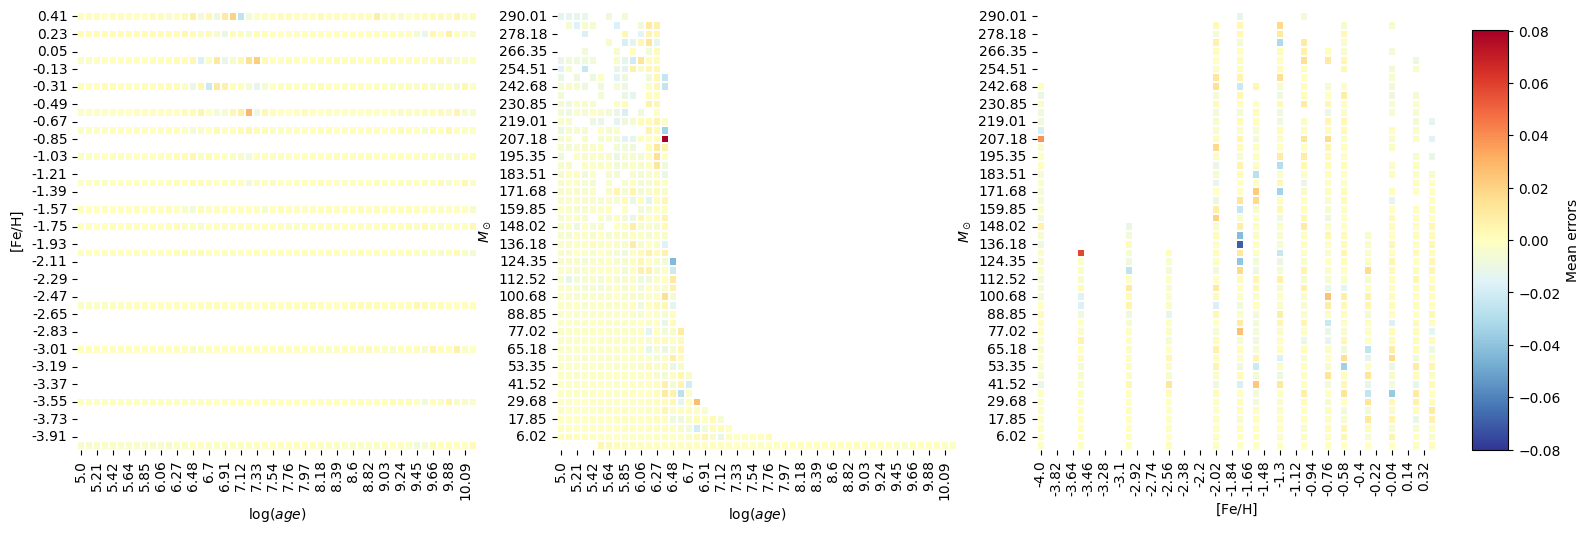

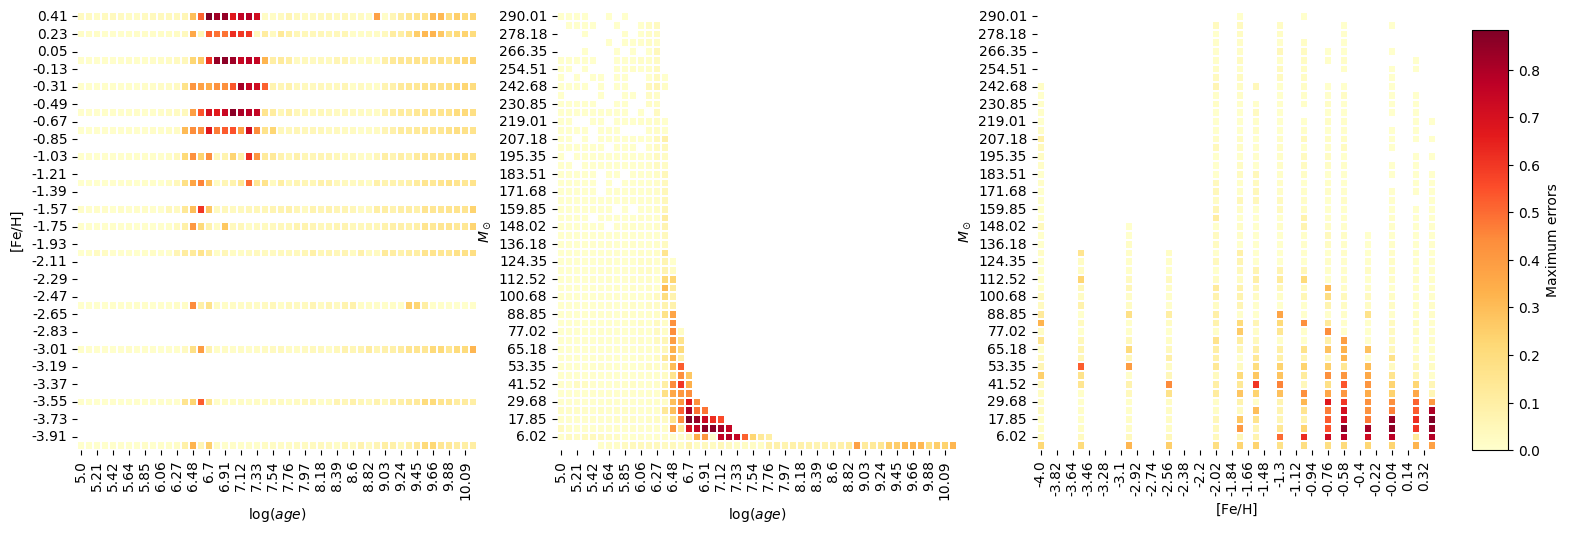

1.9356953373517172e-08

log_g results for the phase category with a value of 0.0
  value range :  -0.5973100835175252 - 5.433094523832443
  RVE :  0.7539132071610324
  RMSE :  0.3127520751336519
  MAE :  0.06812051957471778
  MedAE :  0.0059992008463500834
  CORR :  0.8972133966851478
  MAX_ER :  5.131070218271778
  Percentiles : 
    75th percentile :  0.019406514678643738
    90th percentile :  0.061936003300083316
    95th percentile :  0.18239831523164254
    99th percentile :  1.7412196876746246

log_g results for the phase category with a value of 2.0
  value range :  -0.3287802371627256 - 4.403503445748651
  RVE :  0.5962009029044633
  RMSE :  0.579695517442048
  MAE :  0.2578412318839945
  MedAE :  0.02312240630005613
  CORR :  0.7750667336130296
  MAX_ER :  4.262954864344665
  Percentiles : 
    75th percentile :  0.16169673658263928
    90th percentile :  0.9960349308841663
    95th percentile :  1.484080627883776
    99th percentile :  2.28926110600121

log_g results for the

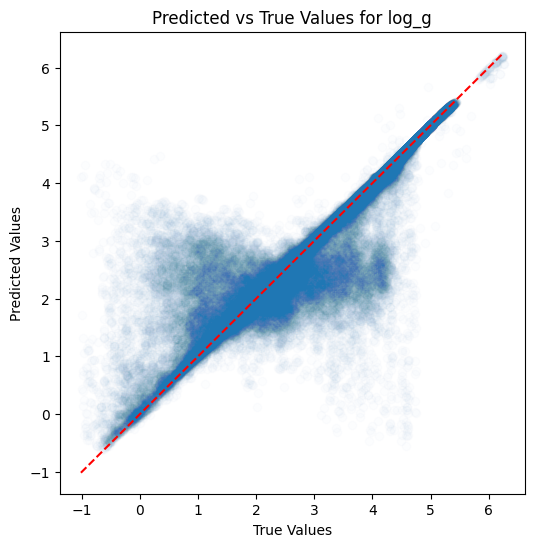

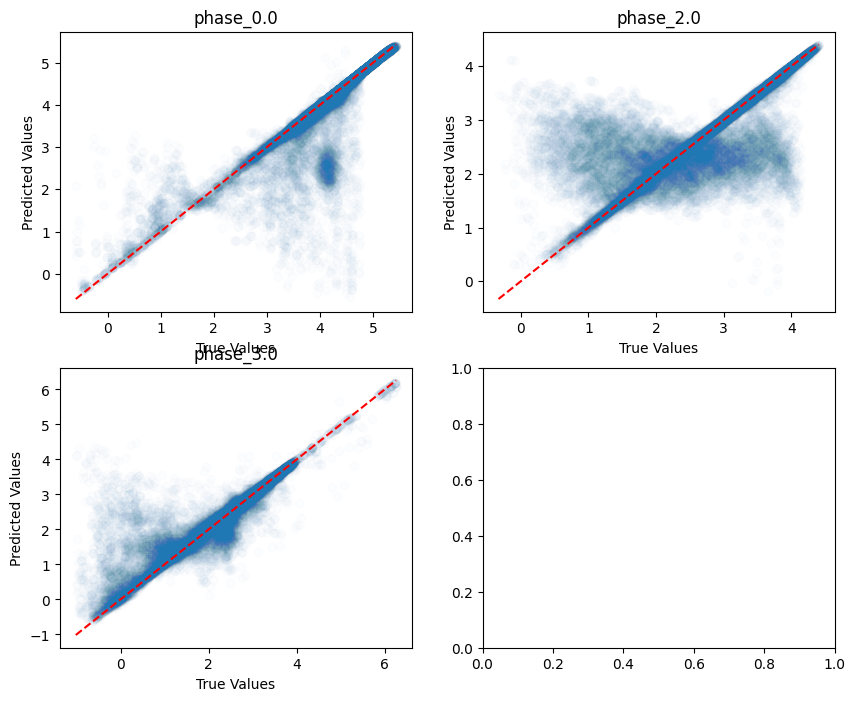

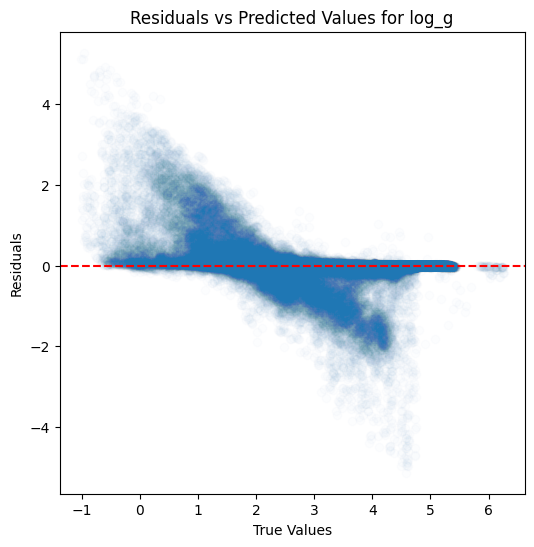

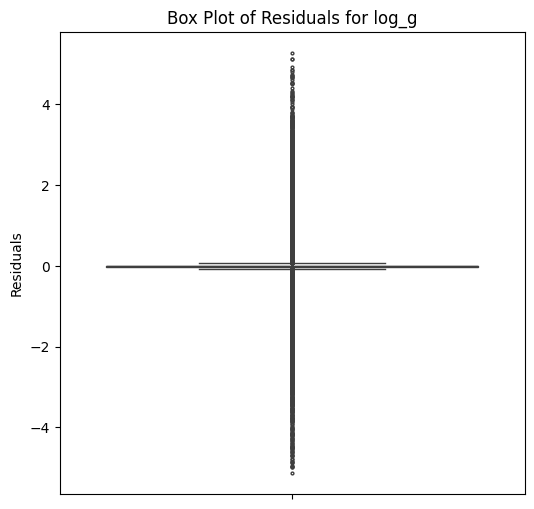

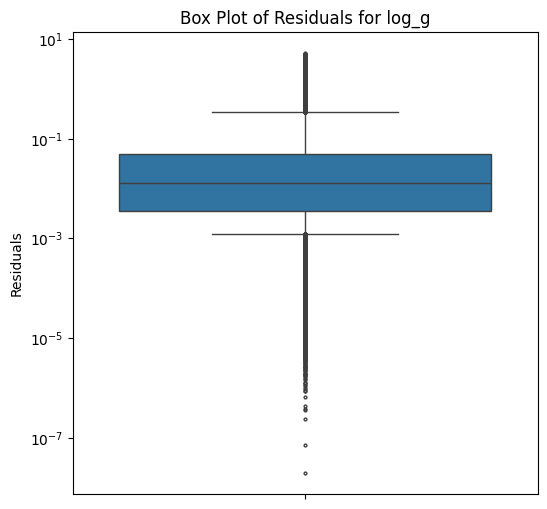

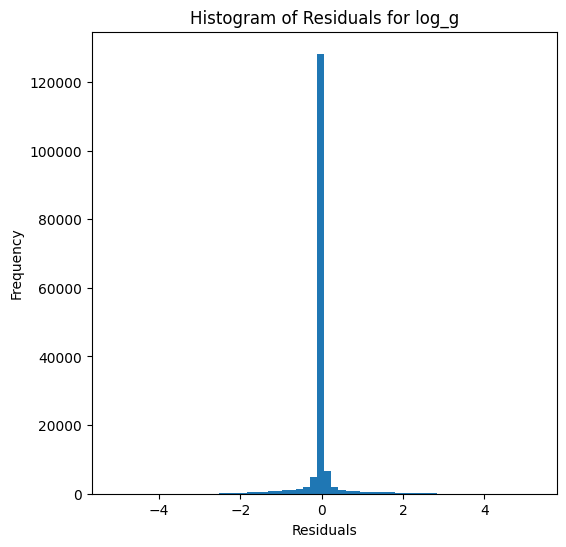

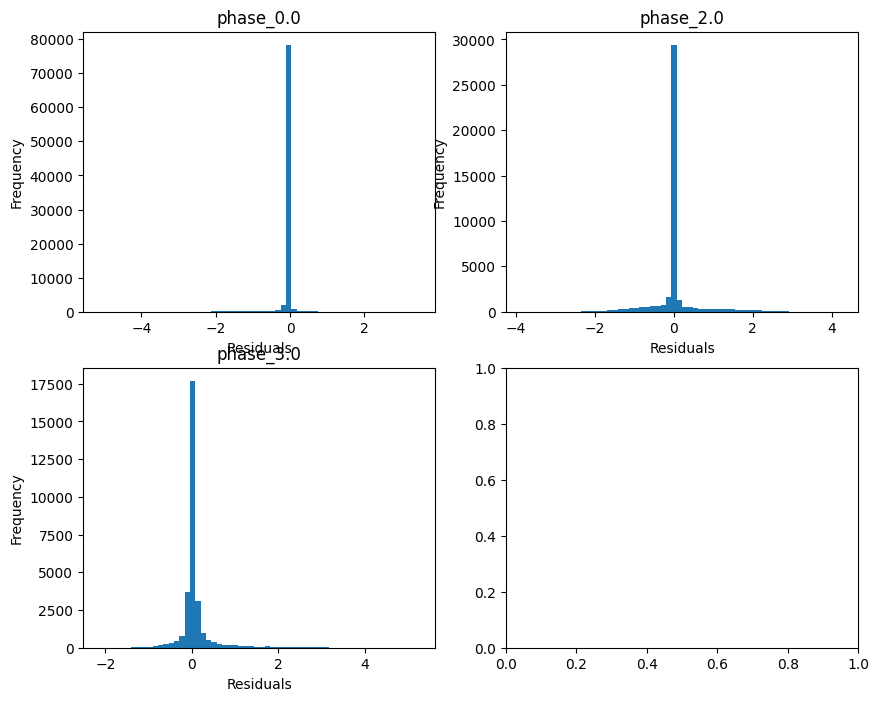

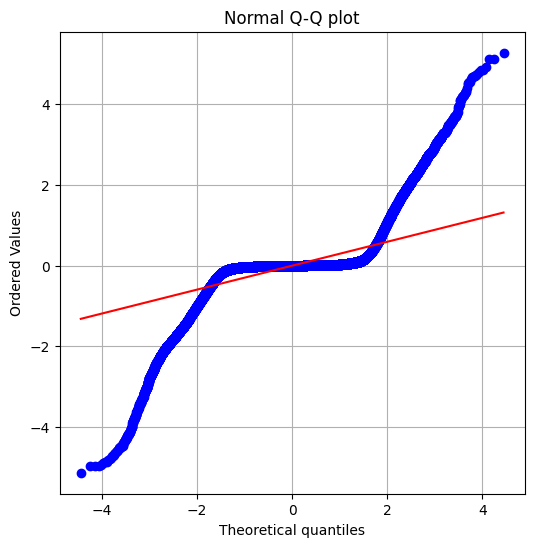

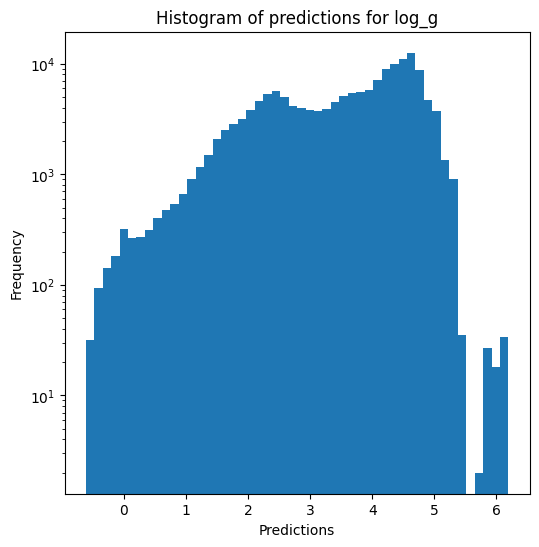

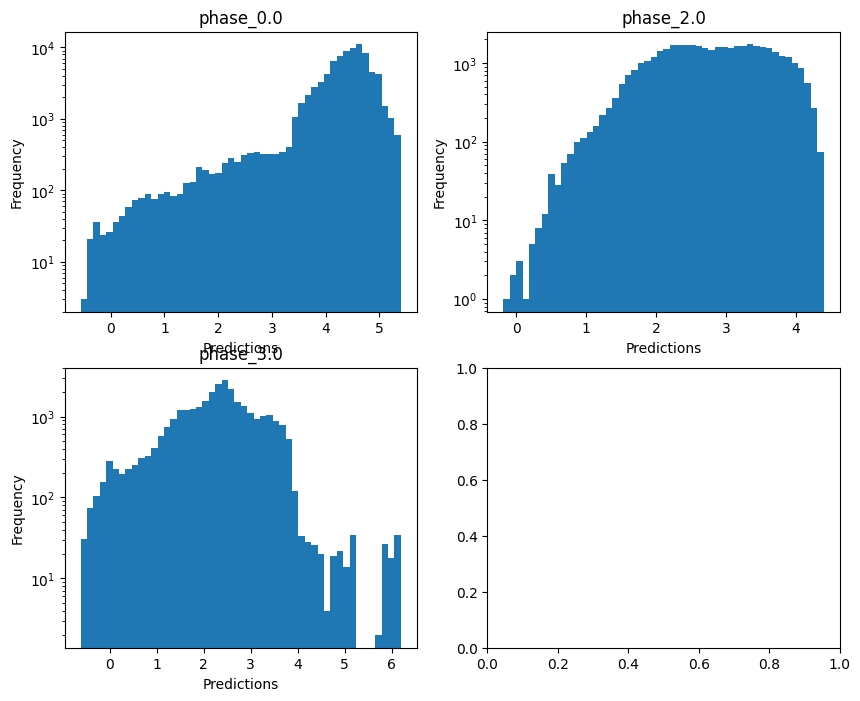

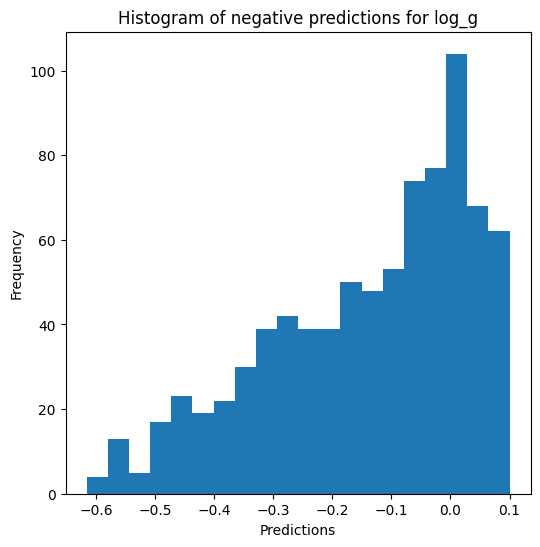

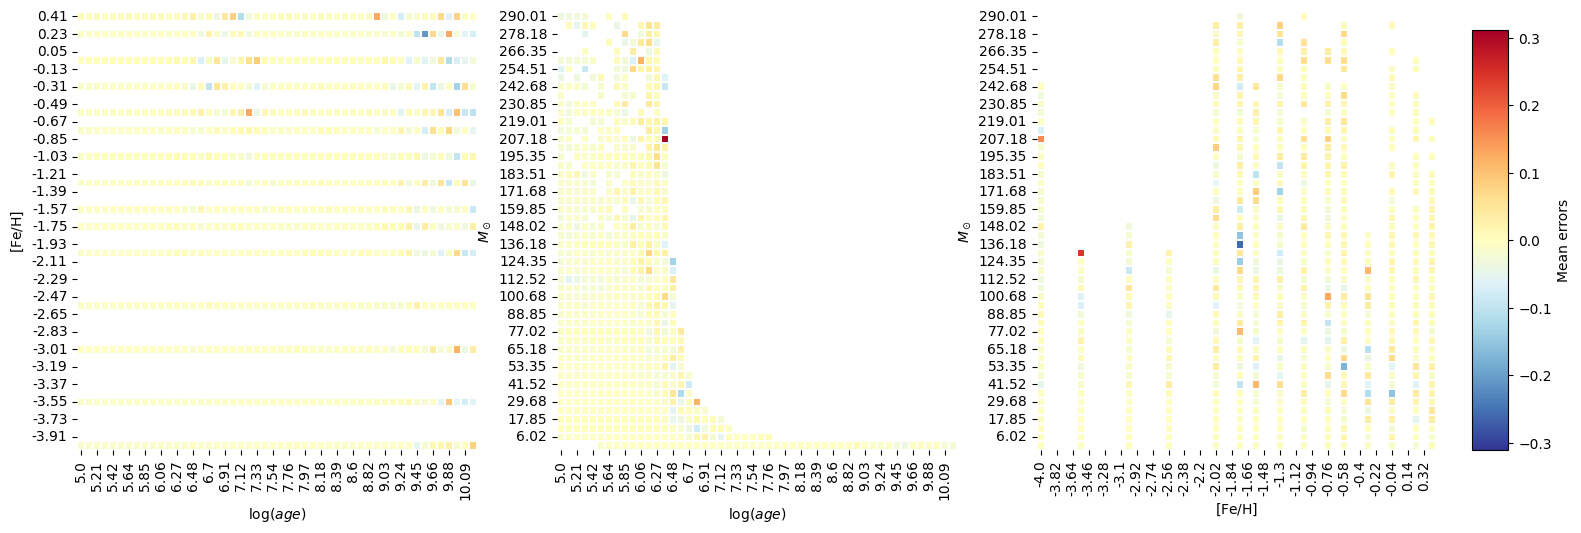

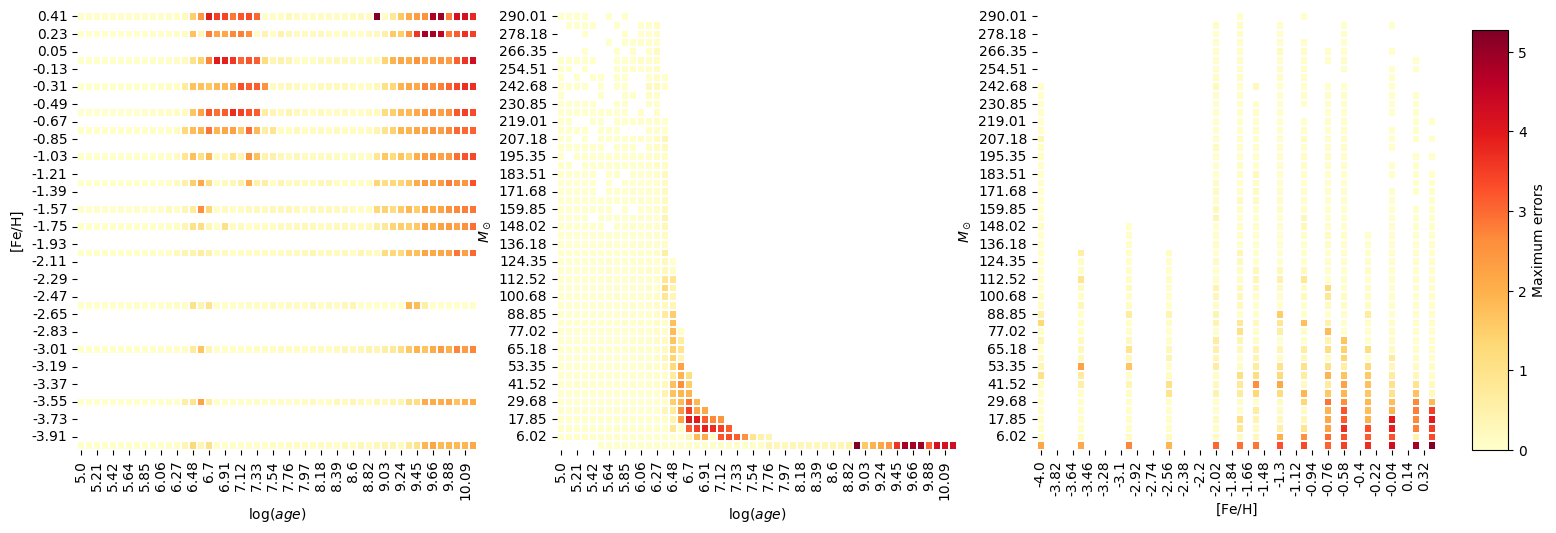

6.353166162598178e-08

radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9259778425217776
  RMSE :  0.15657100501736573
  MAE :  0.034996966089112014
  MedAE :  0.0040451102228863944
  CORR :  0.9648292790338943
  MAX_ER :  2.5669641570606925
  Percentiles : 
    75th percentile :  0.01143358955802197
    90th percentile :  0.03246385275236477
    95th percentile :  0.09168556972099262
    99th percentile :  0.8717018219448098

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.6518767534168086
  RMSE :  0.28984345470024053
  MAE :  0.12892277078418482
  MedAE :  0.011574414869363392
  CORR :  0.8115557757299364
  MAX_ER :  2.130474136009967
  Percentiles : 
    75th percentile :  0.08087754138142261
    90th percentile :  0.4980362314968655
    95th percentile :  0.7419618044948149
    99th percentile :  1.1445972885229374

radius result

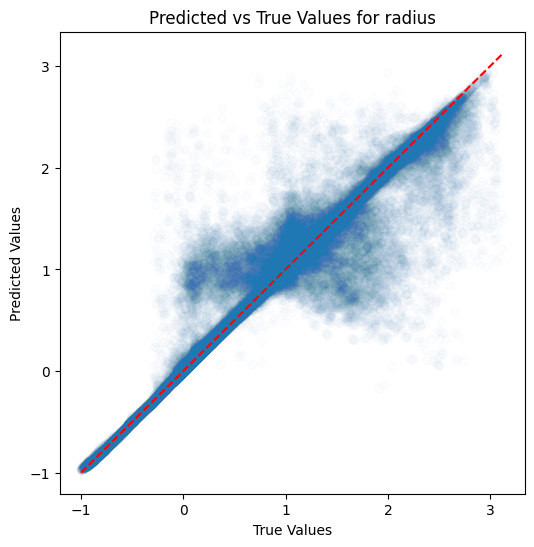

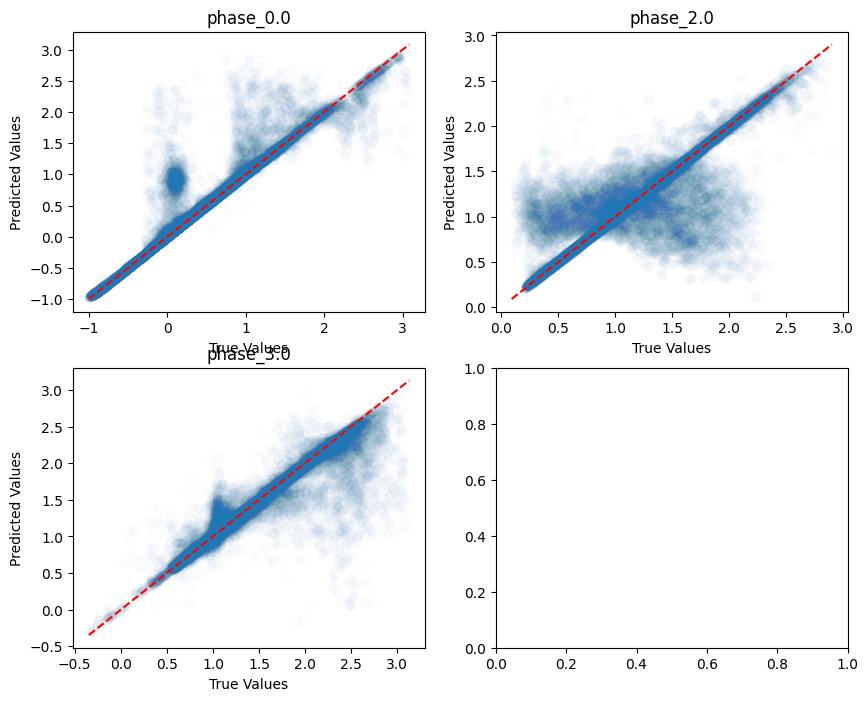

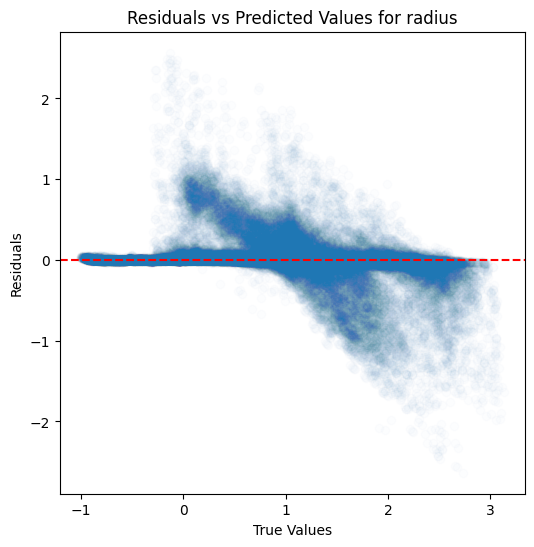

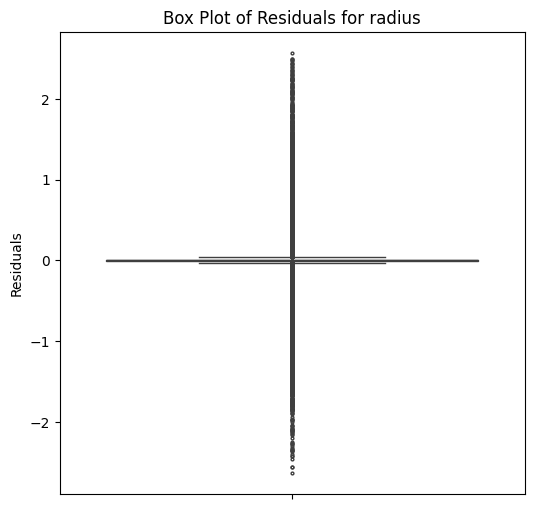

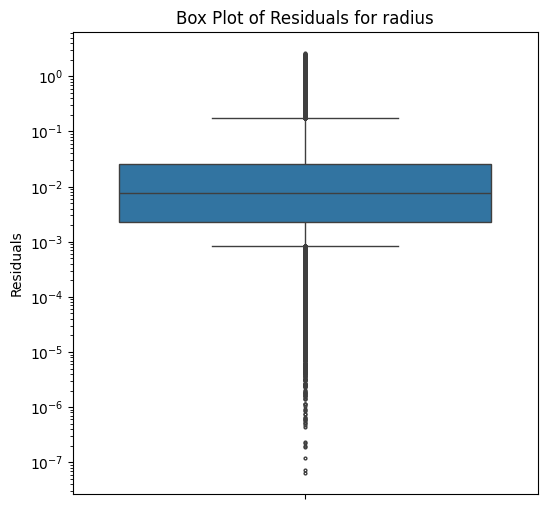

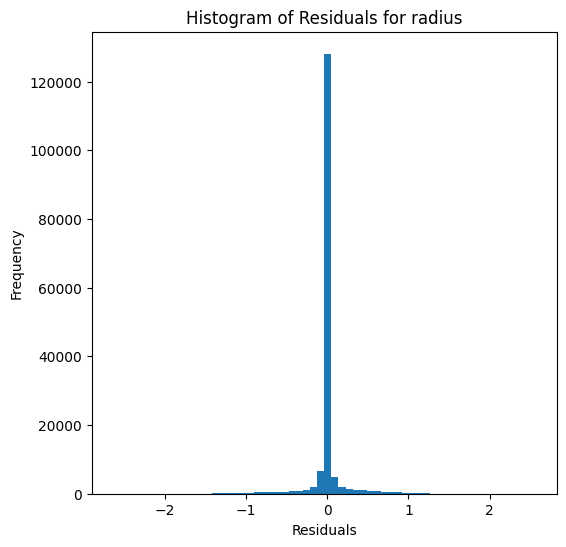

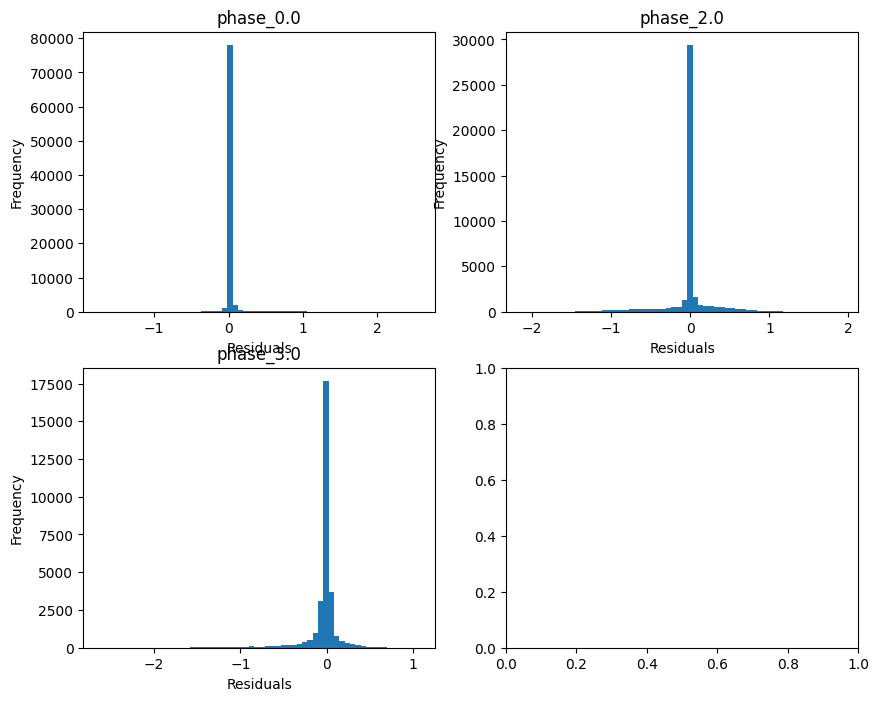

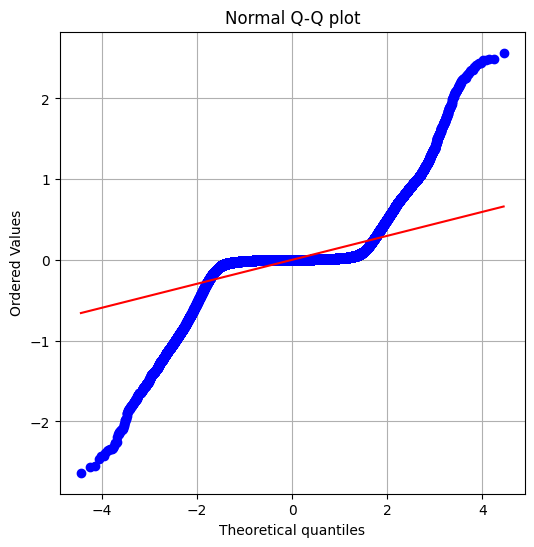

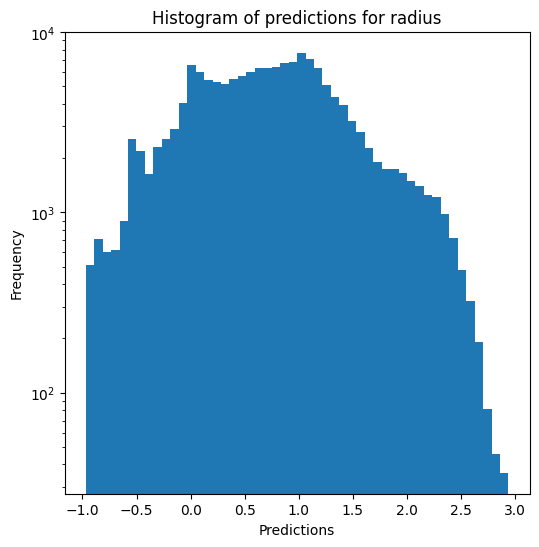

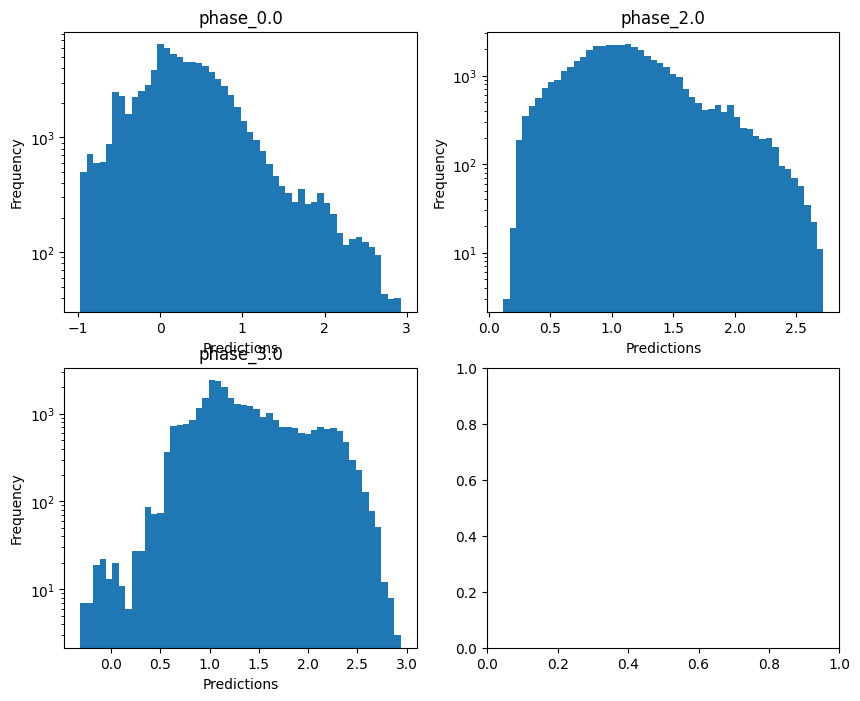

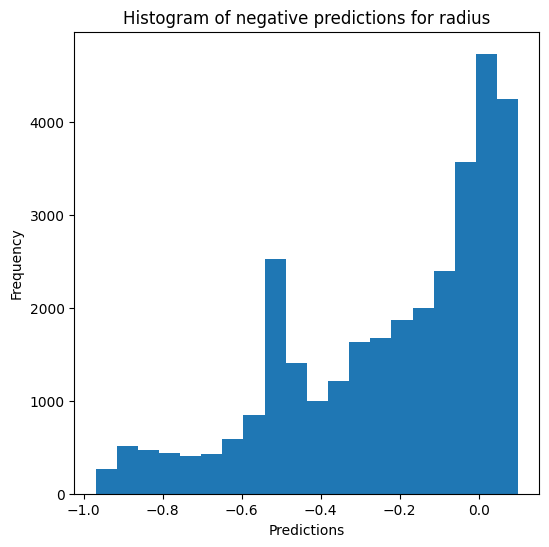

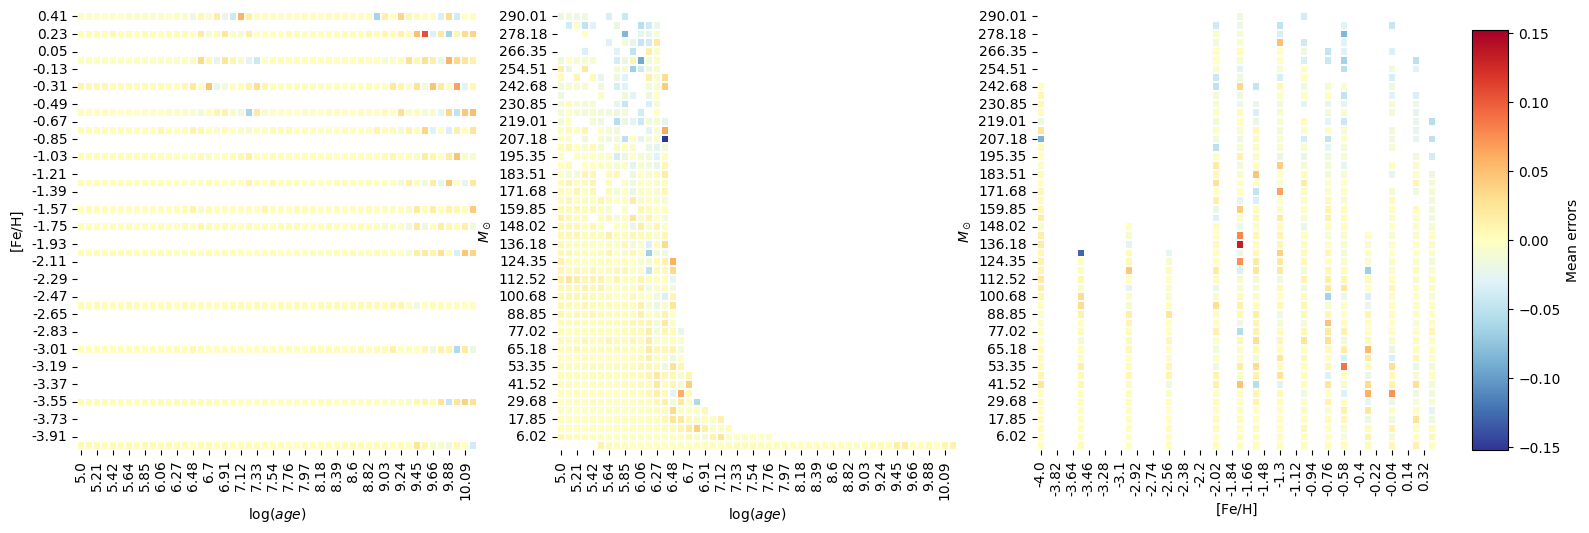

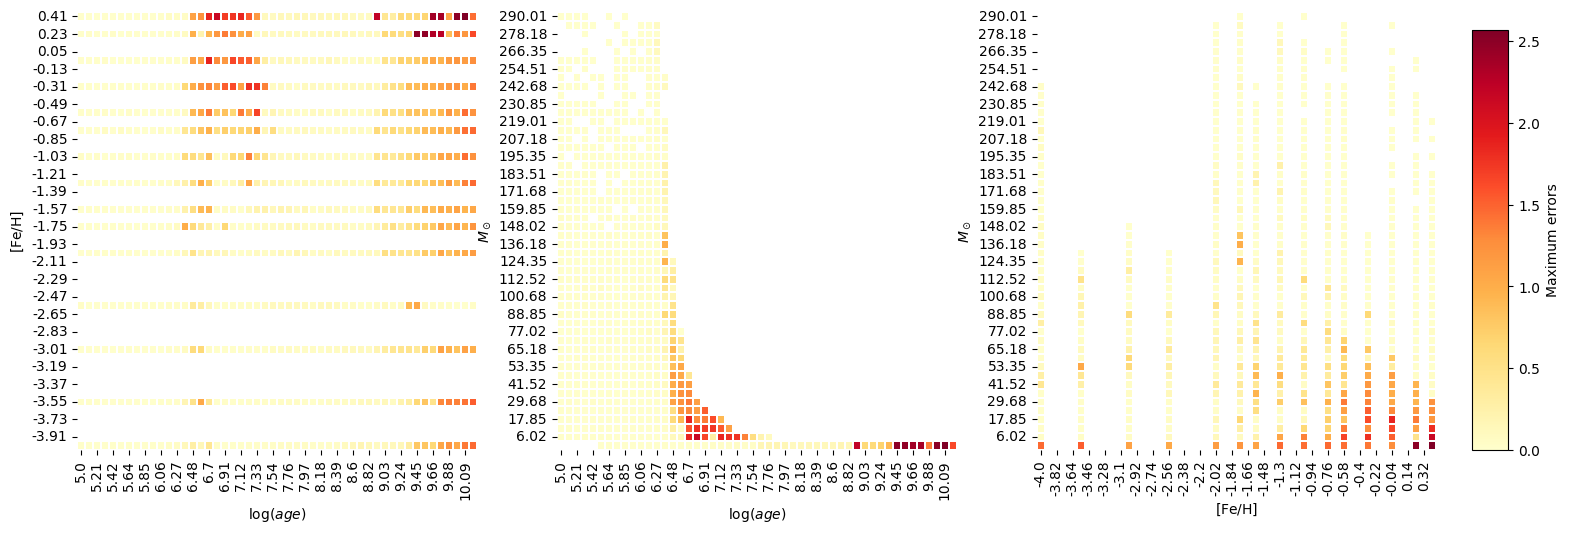

Saving results...


In [13]:
best_params_RF = {'n_jobs':10, 'n_estimators': 300, 'criterion': 'friedman_mse', 'max_depth': 50, 'min_samples_leaf': 5, 'min_samples_split': 2, 'max_features': 'log2', 'max_leaf_nodes': None}

evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(RandomForestRegressor, X_train_quantile, X_ivs_quantile, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=override, use_preds=use_preds, save=save, show=show, 
                               inputs=X_ivs, inputs_col_names=input_col_names, output_col_names=output_col_names, **best_params_RF)

## KNN

In [10]:
tag = "scale_quantile"

../../../../../../results/model_B/final_models/

scale_quantile train data :
Evaluating predictions...
1.2096990076315706e-12
no negative values

T_eff results for the phase category with a value of 0.0
  value range :  3.3447003632081813 - 4.903113097363014
  RVE :  0.9816405057821322
  RMSE :  0.04772715293195622
  MAE :  0.009735315829397895
  MedAE :  0.0013892860330892987
  CORR :  0.9908258257505311
  MAX_ER :  0.84147800586365
  Percentiles : 
    75th percentile :  0.002990535464164612
    90th percentile :  0.0072013839714062024
    95th percentile :  0.020989183203414793
    99th percentile :  0.24804559970764414

T_eff results for the phase category with a value of 2.0
  value range :  3.424526073183654 - 4.703420536058761
  RVE :  0.9866366783685924
  RMSE :  0.03659117347690074
  MAE :  0.01666917391707295
  MedAE :  0.003224240548522772
  CORR :  0.9933073954836731
  MAX_ER :  0.5576884435342575
  Percentiles : 
    75th percentile :  0.014121301315089596
    90th percent

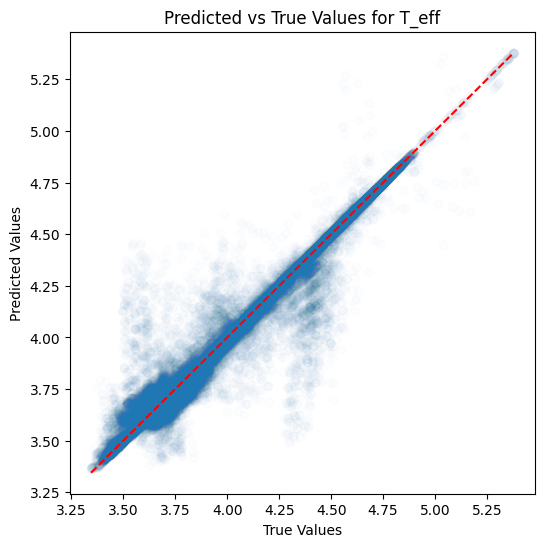

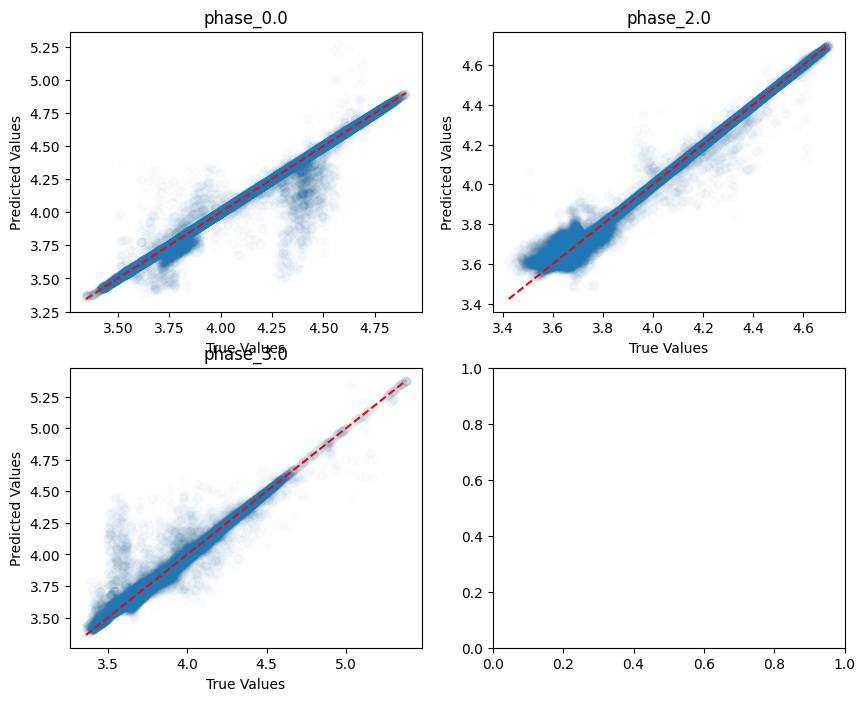

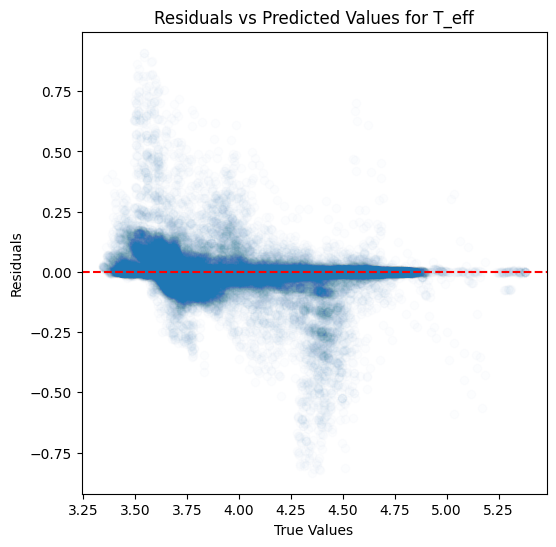

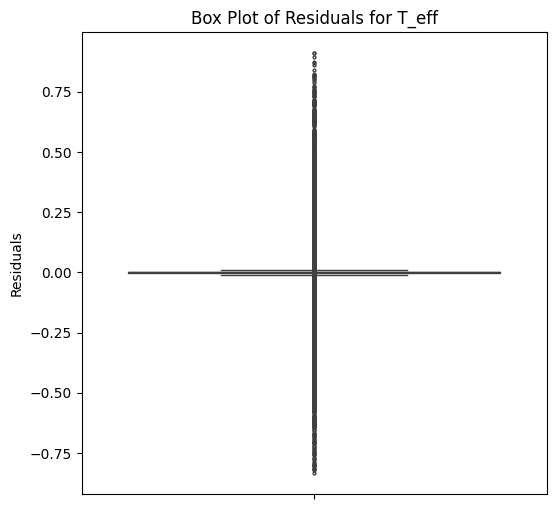

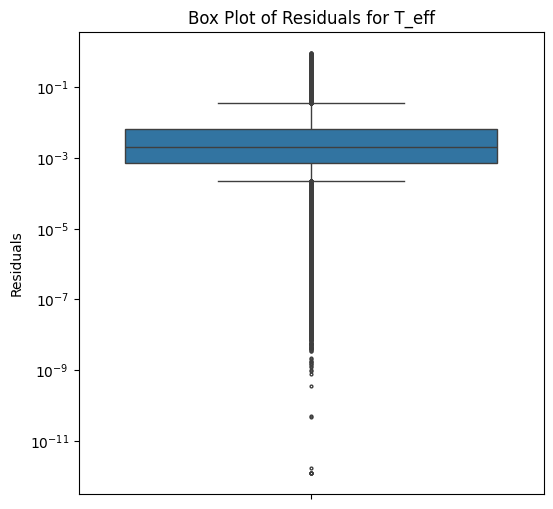

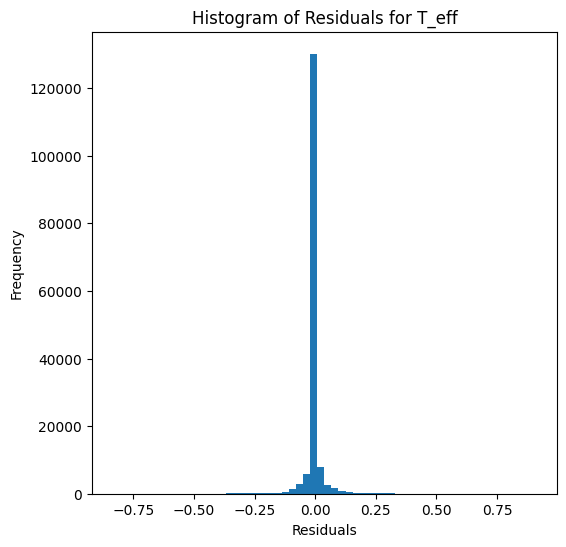

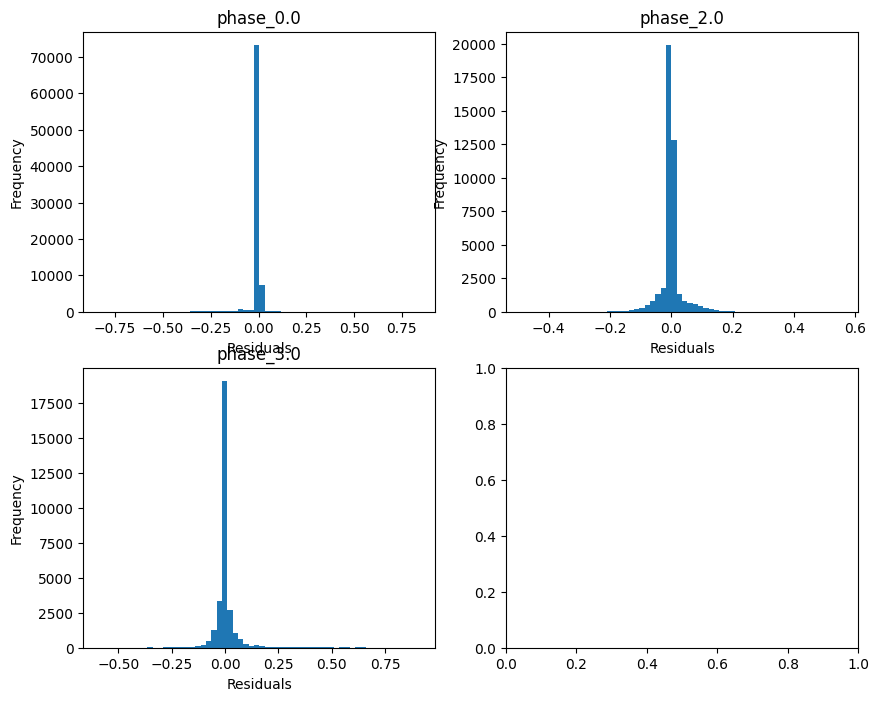

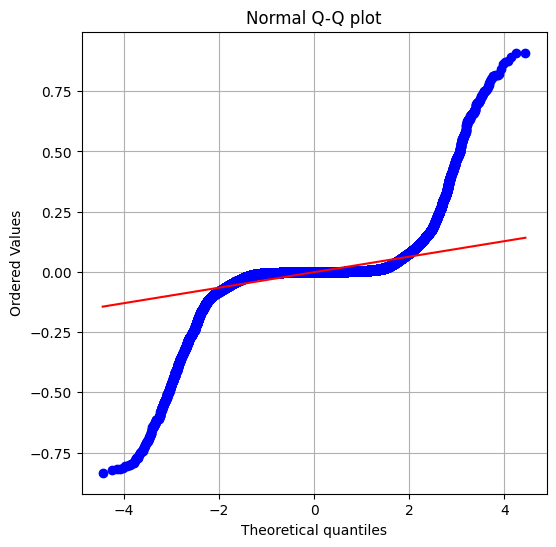

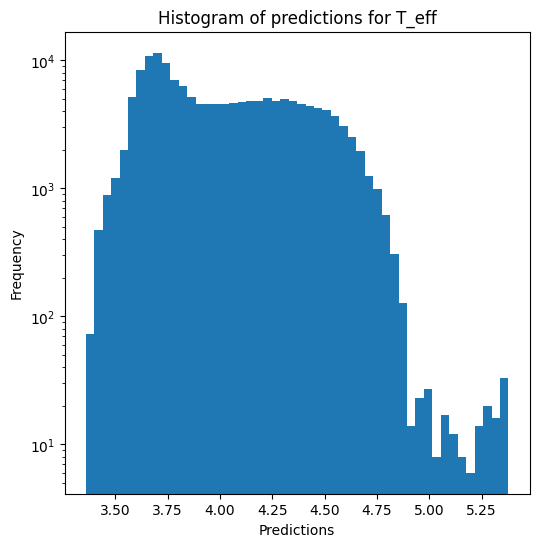

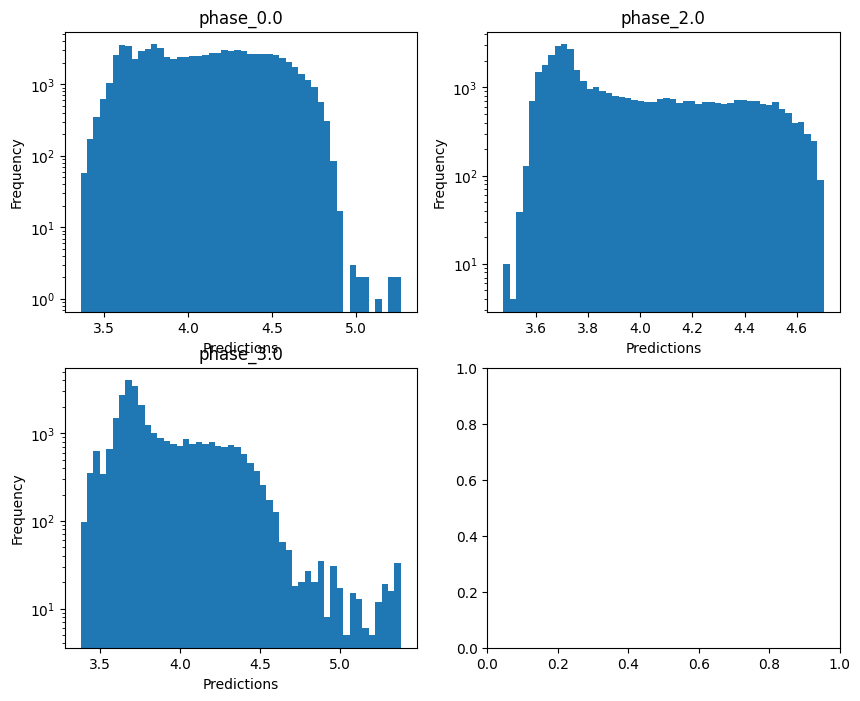

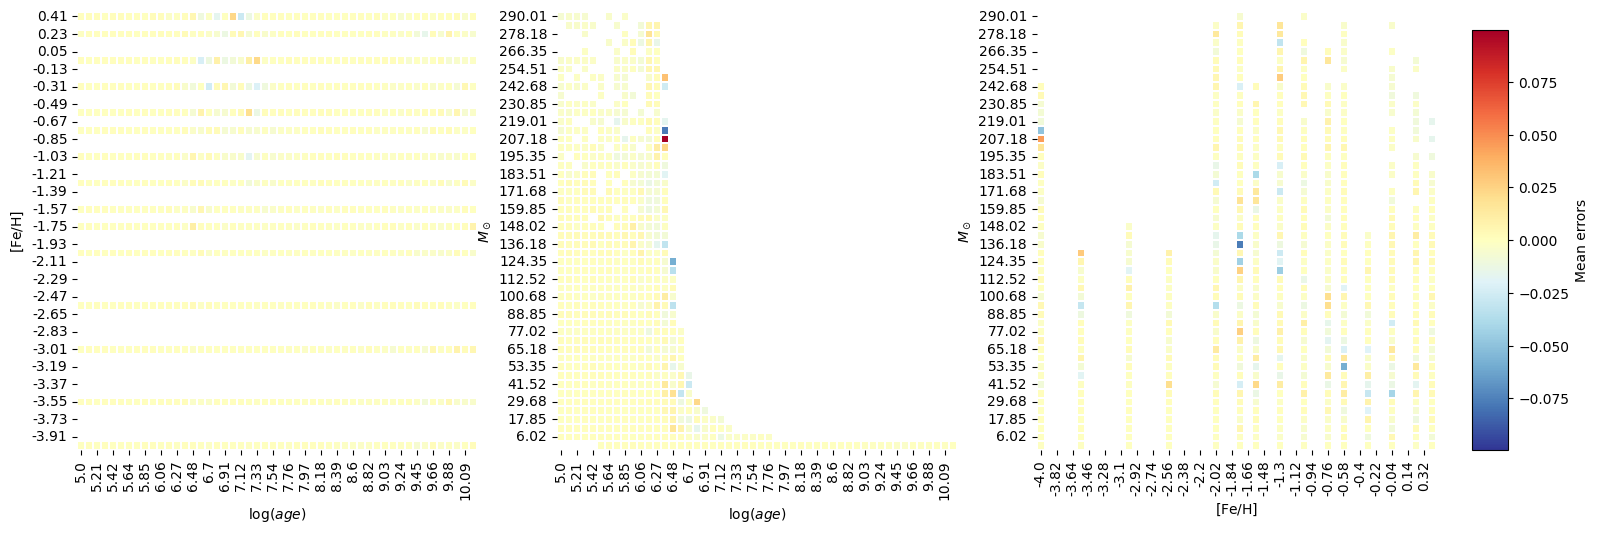

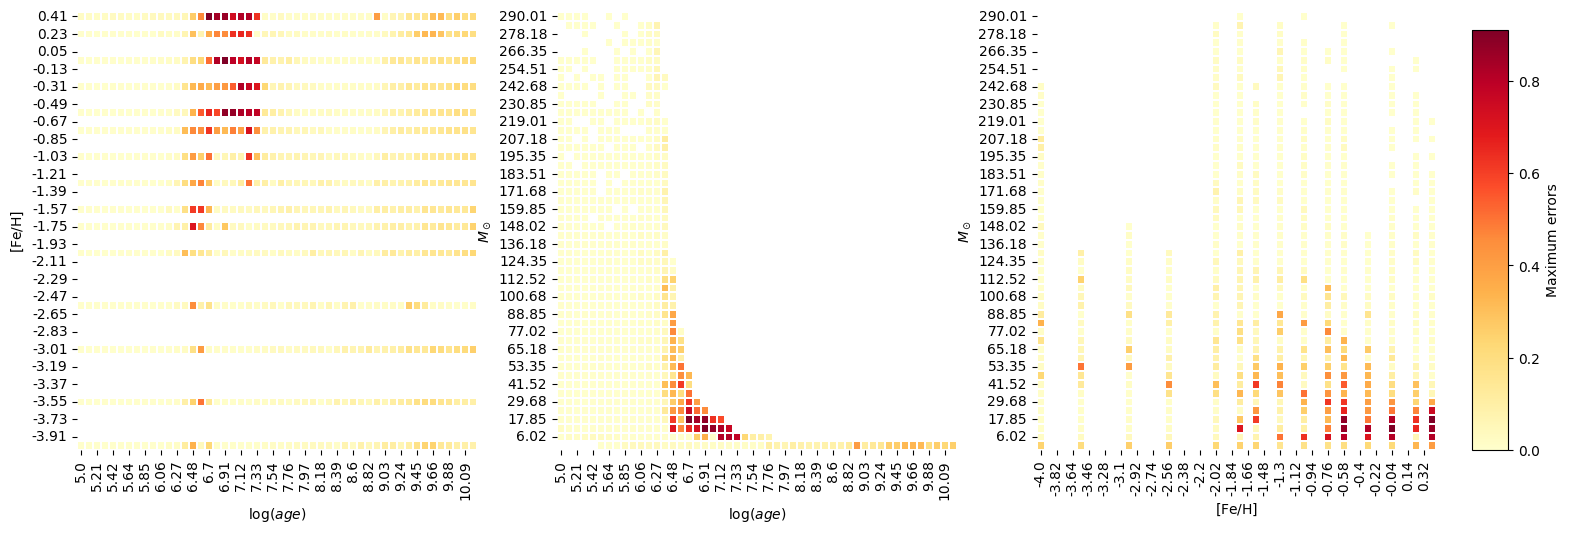

5.766498389903063e-12

log_g results for the phase category with a value of 0.0
  value range :  -0.5973100835175252 - 5.433094523832443
  RVE :  0.7171323187363532
  RMSE :  0.3337304808909611
  MAE :  0.06365537066194563
  MedAE :  0.0031200167254943345
  CORR :  0.8847918959848986
  MAX_ER :  5.476894166411275
  Percentiles : 
    75th percentile :  0.010164215239571783
    90th percentile :  0.02580622575490726
    95th percentile :  0.08875522432443383
    99th percentile :  1.759959121934399

log_g results for the phase category with a value of 2.0
  value range :  -0.3287802371627256 - 4.403503445748651
  RVE :  0.6414089810294669
  RMSE :  0.5459795634326109
  MAE :  0.24327937461244997
  MedAE :  0.015757897581889502
  CORR :  0.8020241851847806
  MAX_ER :  4.007698539742984
  Percentiles : 
    75th percentile :  0.17430741099497404
    90th percentile :  0.9506130693581892
    95th percentile :  1.40178484741294
    99th percentile :  2.13841581626558

log_g results for the 

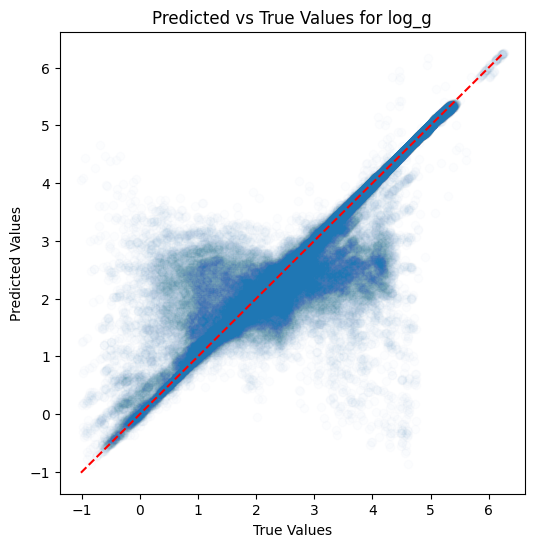

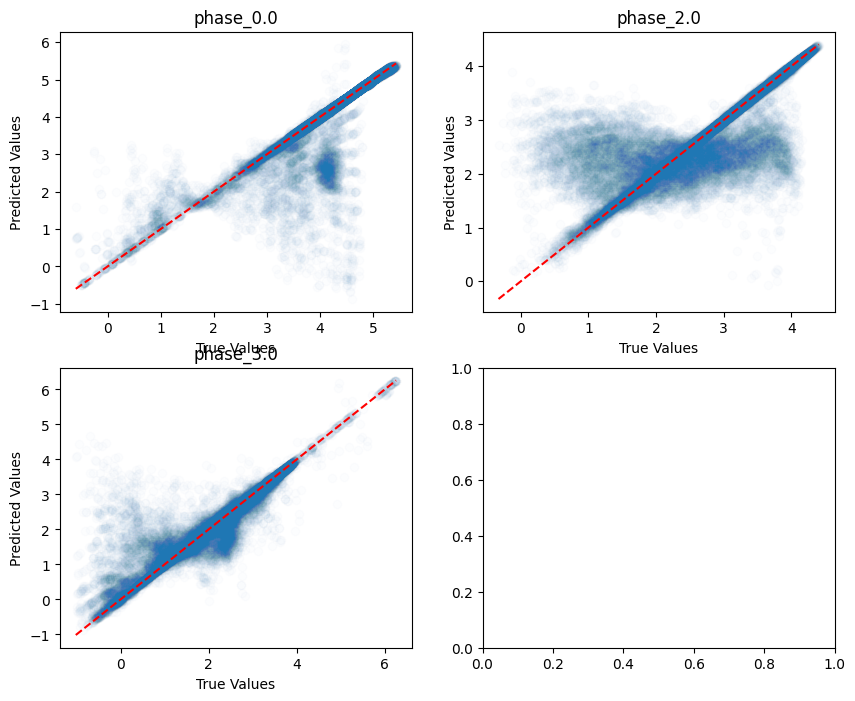

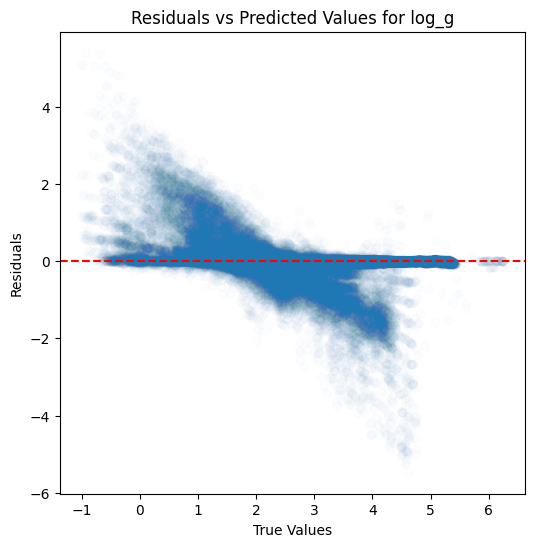

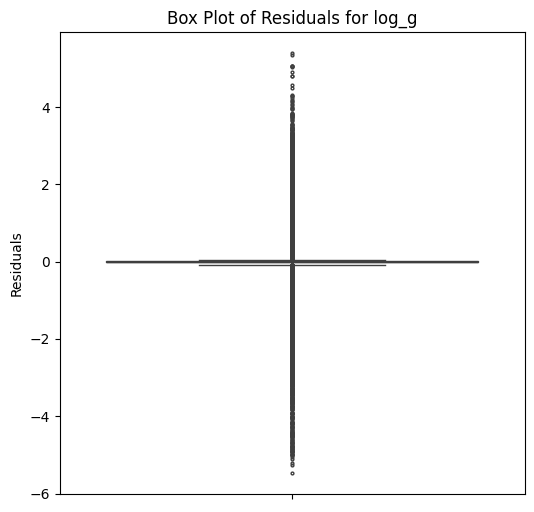

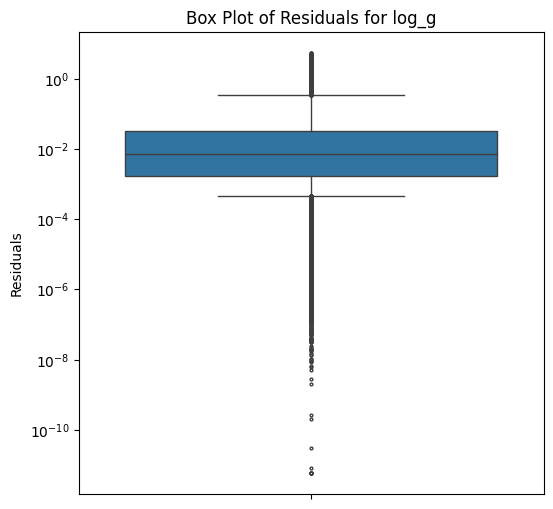

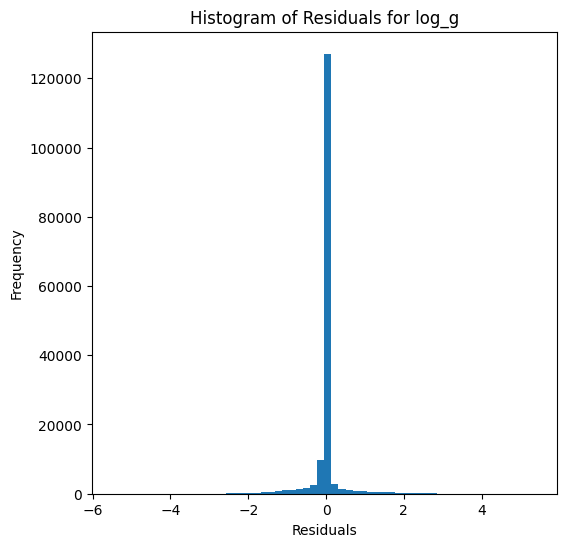

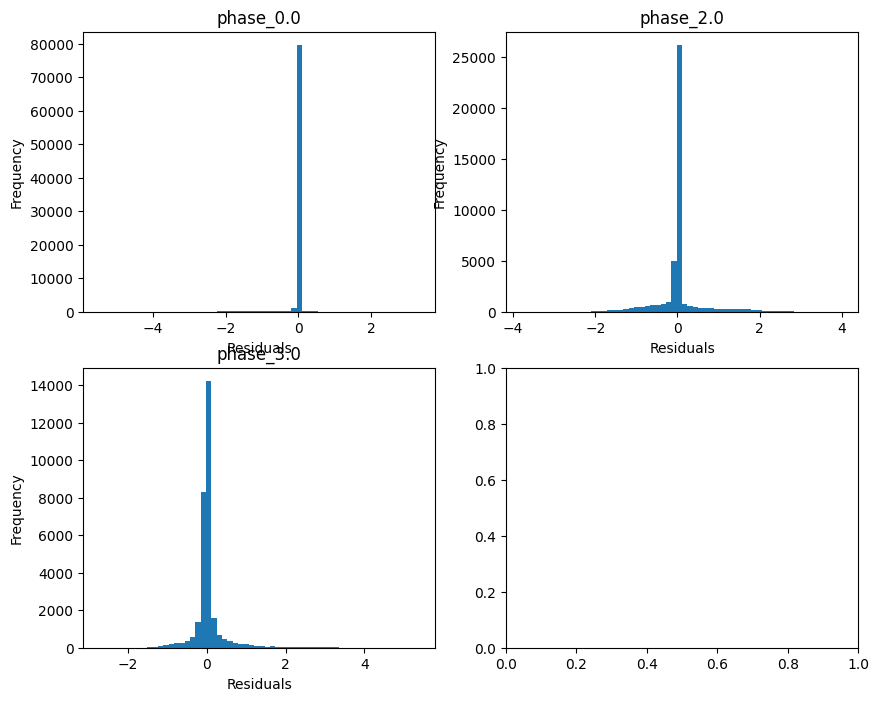

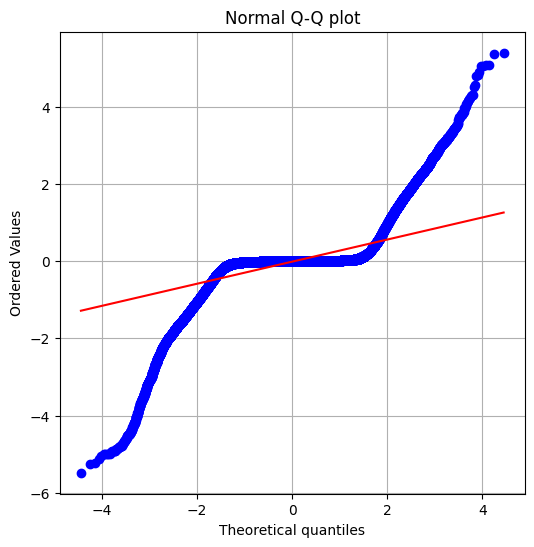

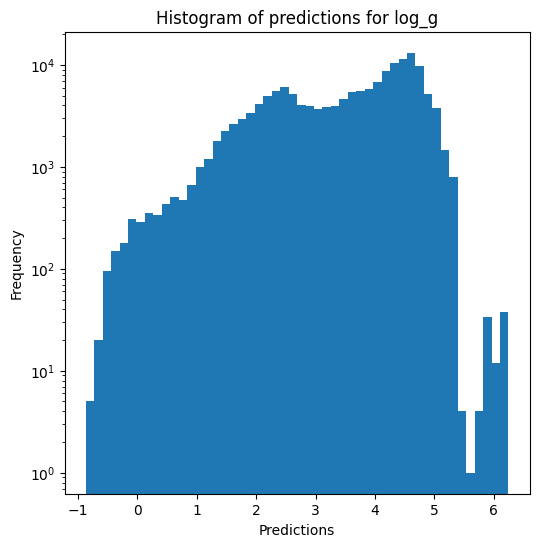

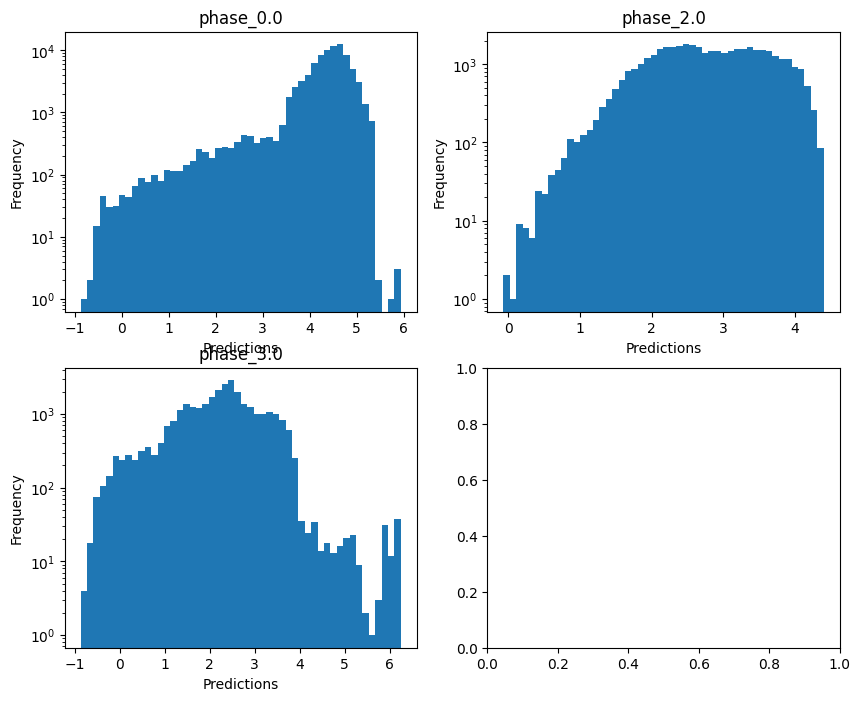

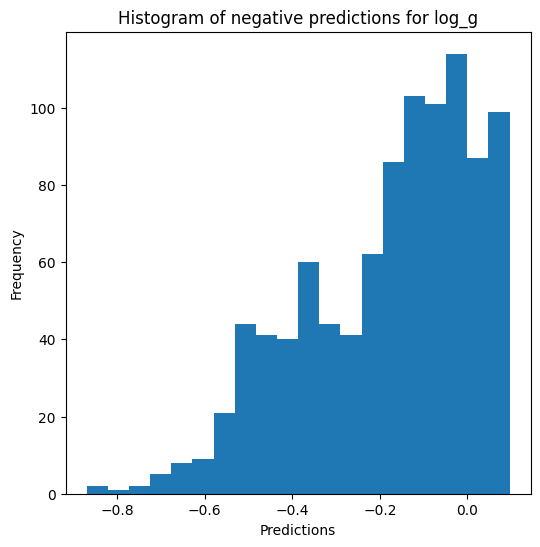

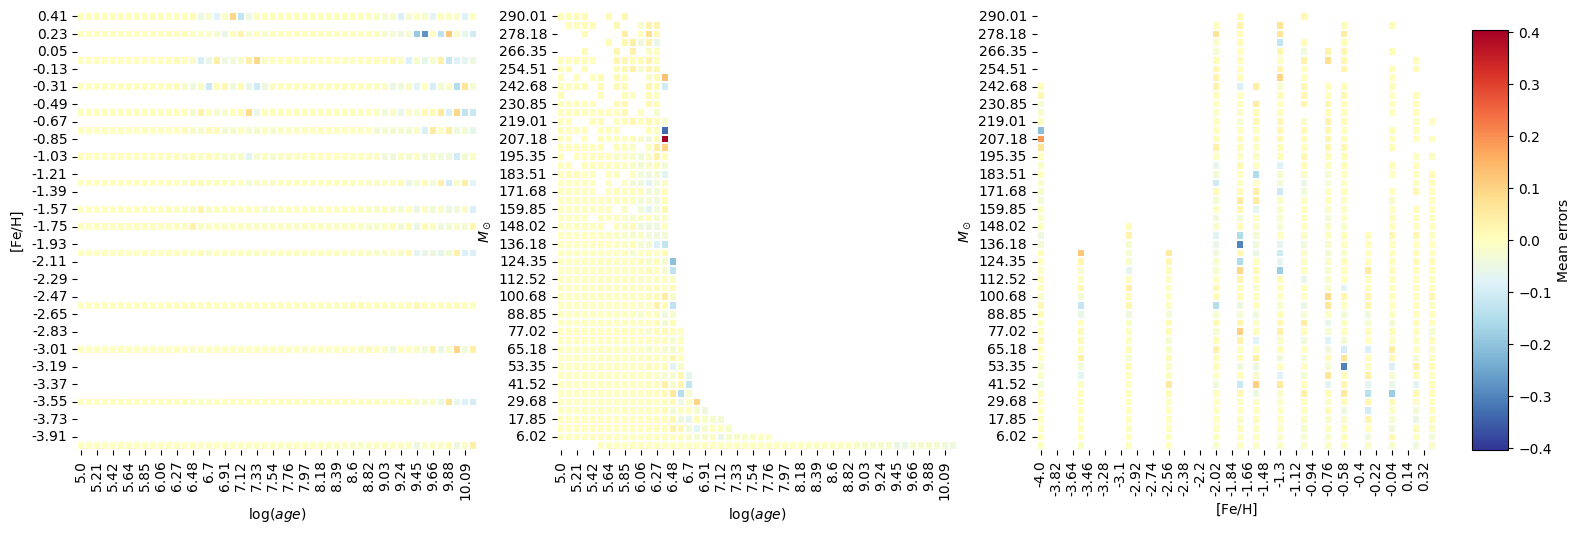

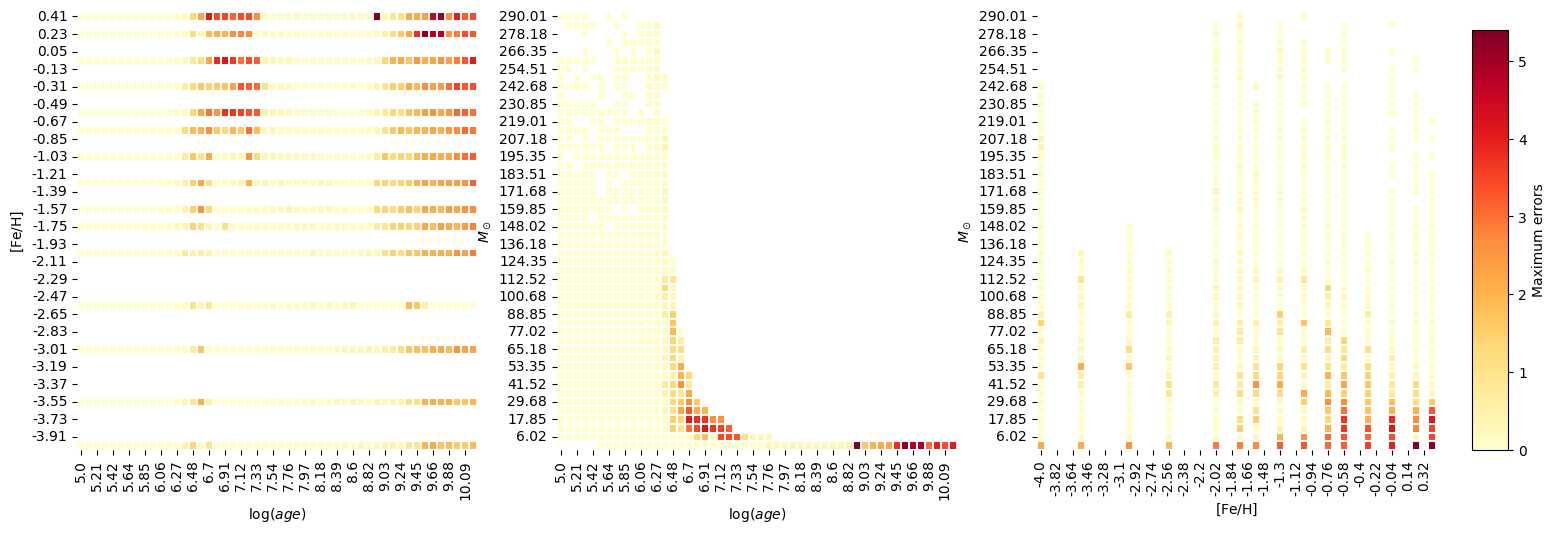

2.8974600496667335e-12

radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9148028787528736
  RMSE :  0.16719562221554368
  MAE :  0.03370986590442329
  MedAE :  0.002866281502498076
  CORR :  0.9598665017992231
  MAX_ER :  2.74065180260365
  Percentiles : 
    75th percentile :  0.00748611306378541
    90th percentile :  0.01841047204927742
    95th percentile :  0.06305442749661104
    99th percentile :  0.8814548713487231

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.6908478542807158
  RMSE :  0.27298670539672654
  MAE :  0.12165352533045393
  MedAE :  0.007891673834136359
  CORR :  0.8330691374362877
  MAX_ER :  2.0036206739495976
  Percentiles : 
    75th percentile :  0.08715666718018811
    90th percentile :  0.4753226858923774
    95th percentile :  0.700916161061064
    99th percentile :  1.069225379621785

radius results fo

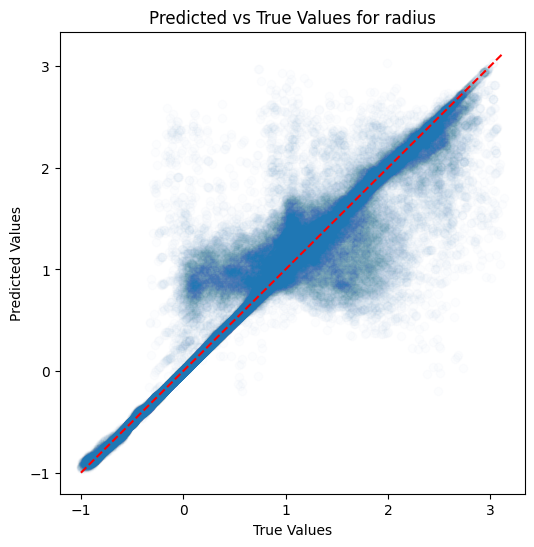

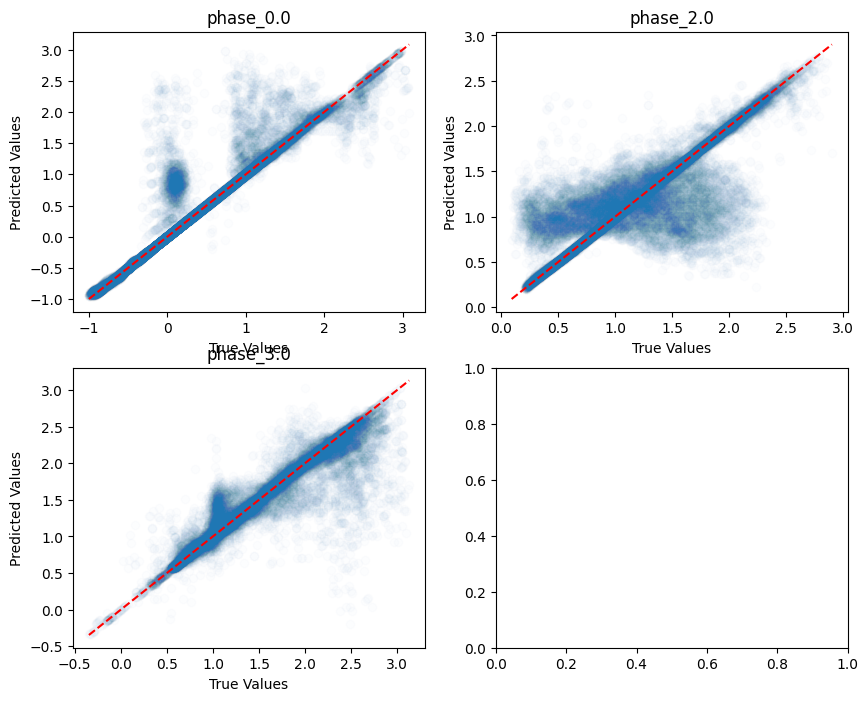

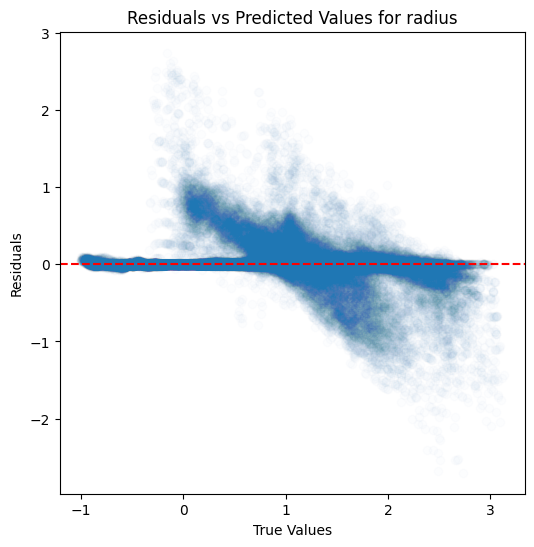

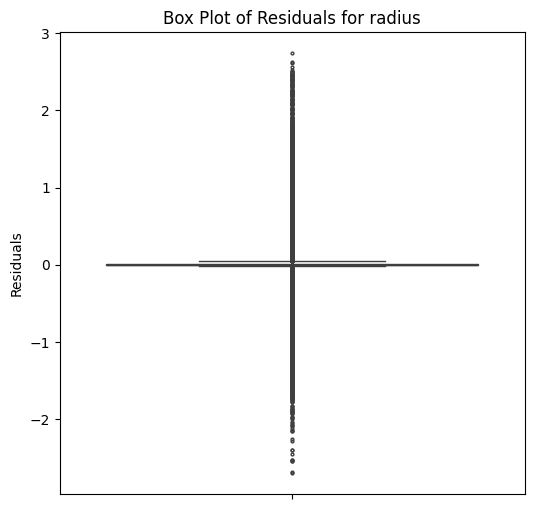

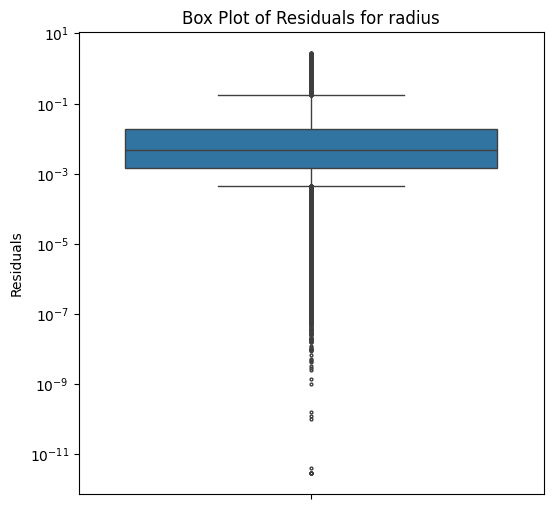

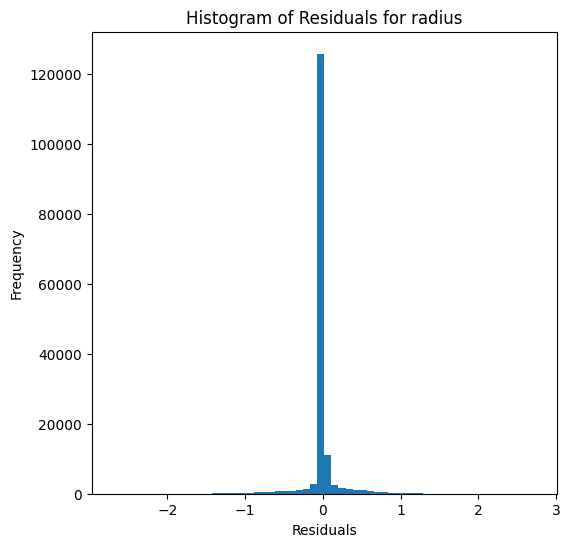

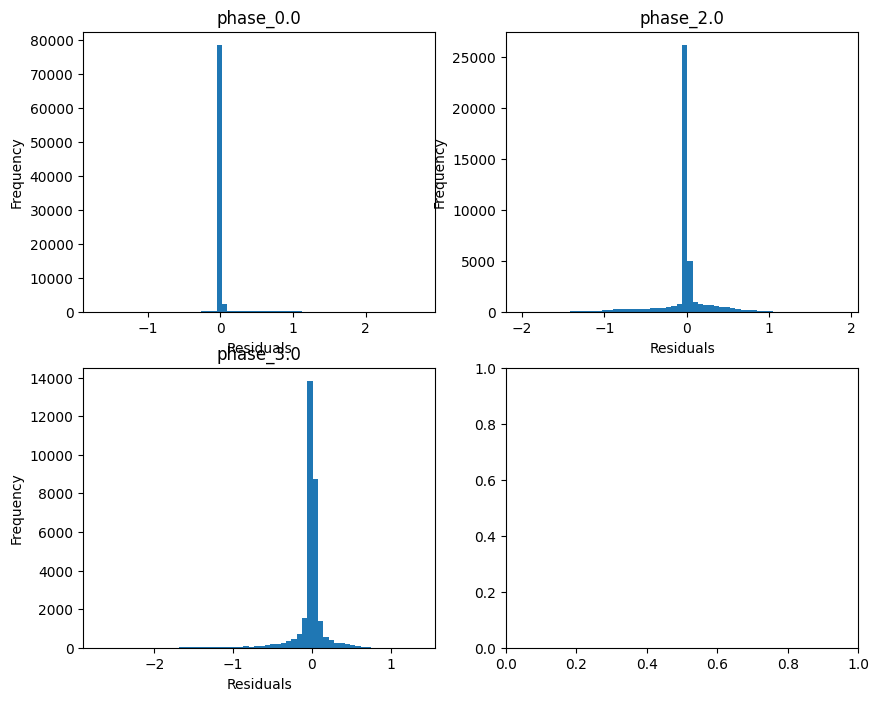

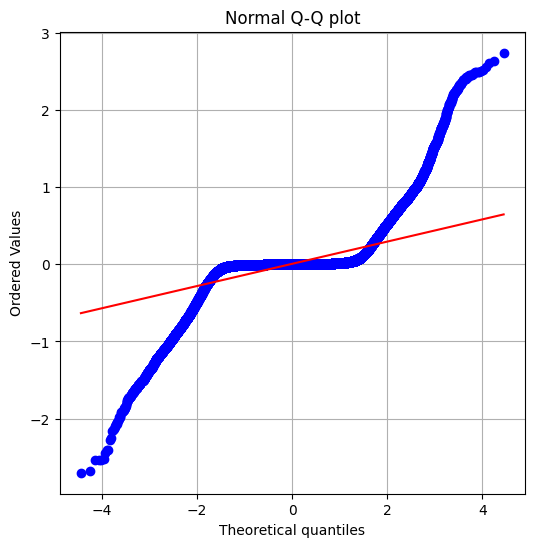

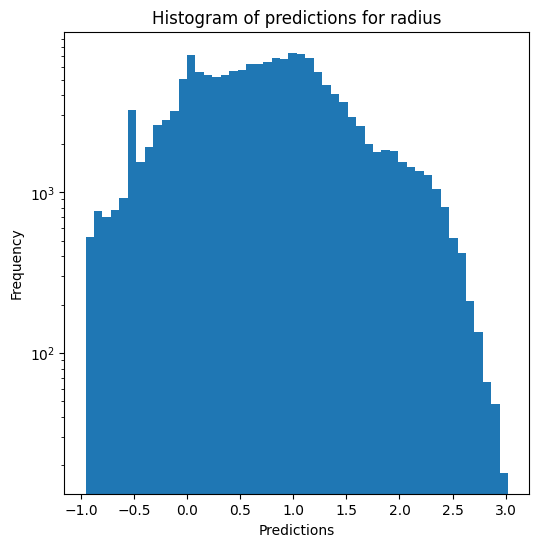

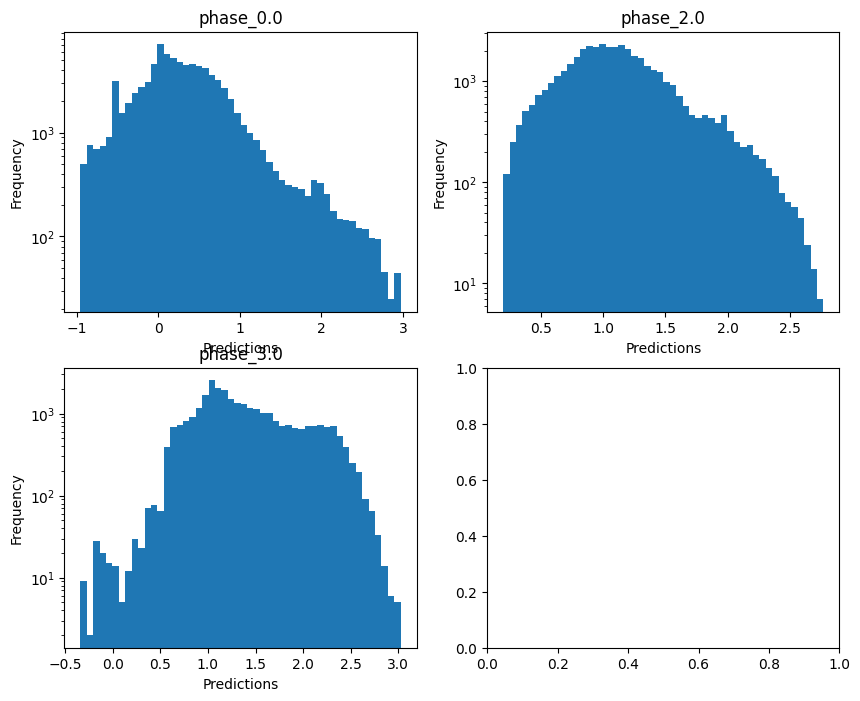

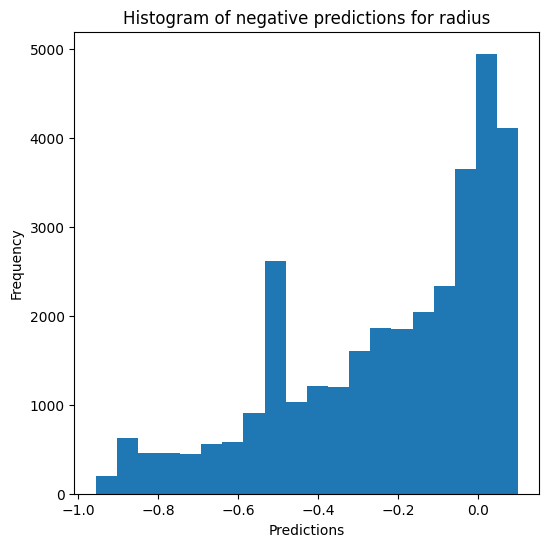

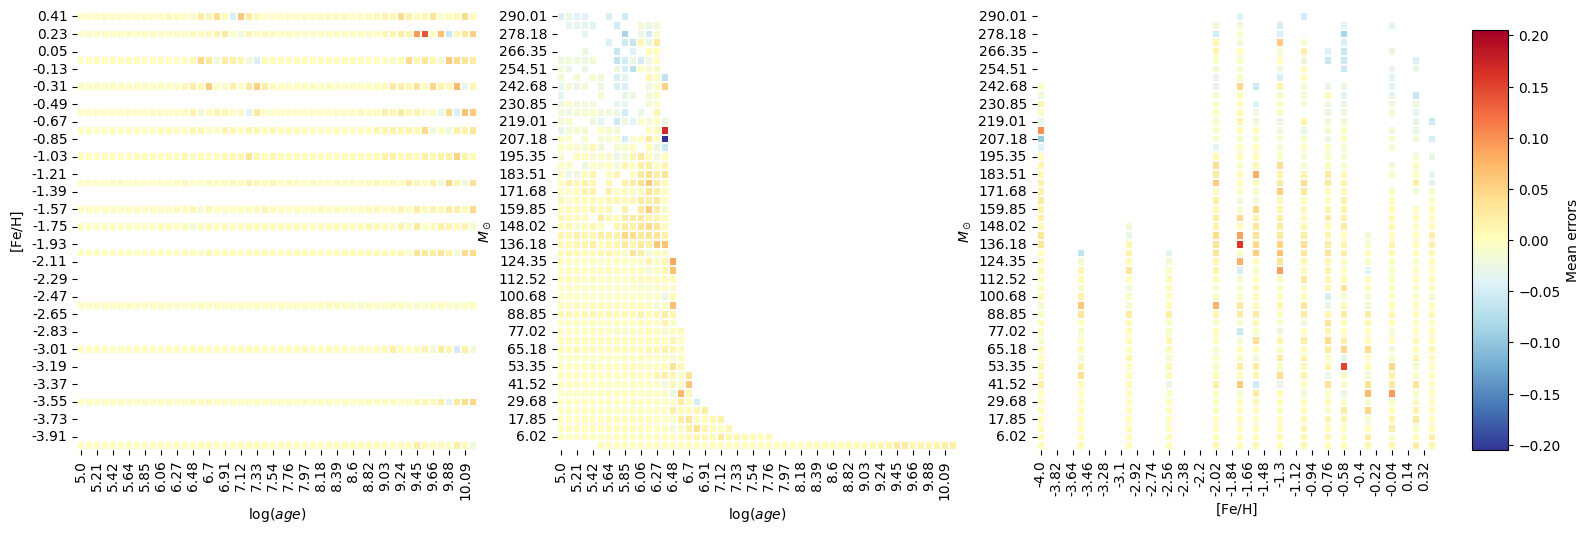

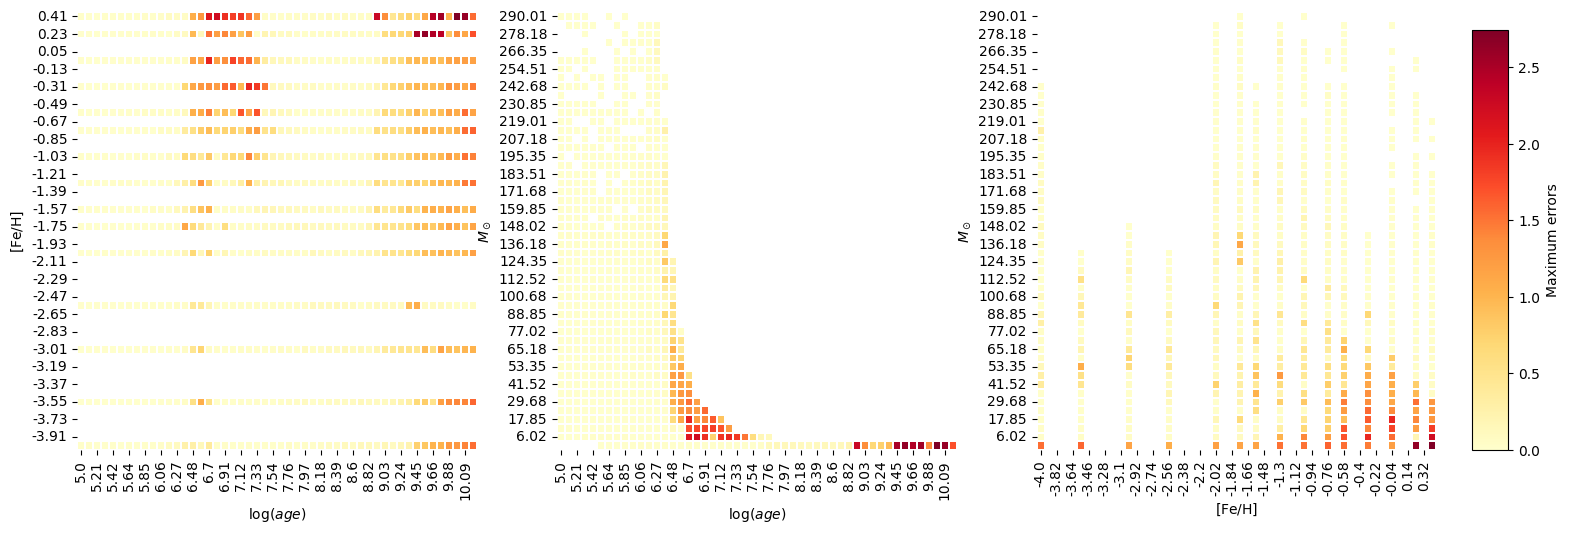

Saving results...


In [11]:
best_params_KNN = {'n_jobs' : 10, 'algorithm': 'kd_tree', 'leaf_size': 15, 'n_neighbors': 10, 'weights': 'uniform'}

print(path_to_results)
evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(KNeighborsRegressor, X_train_quantile, X_ivs_quantile, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=override, use_preds=use_preds, save=save, show=show, 
                               inputs=X_ivs, inputs_col_names=input_col_names, output_col_names=output_col_names, **best_params_KNN)

# Training the final models

In [9]:
X = np.append(X_train, X_ivs, 0)
X_quantile = np.append(X_train_quantile, X_ivs_quantile, 0)
y = np.append(y_train, y_ivs, 0)

print(X.shape)
print(X_quantile.shape)
print(y.shape)

(630605, 3)
(630605, 3)
(630605, 3)


## Random forest

In [22]:
best_params_RF = {'n_jobs':10, 'n_estimators': 300, 'criterion': 'friedman_mse', 'max_depth': 50, 'min_samples_leaf': 5, 'min_samples_split': 2, 'max_features': 'log2', 'max_leaf_nodes': None}

mdl = RandomForestRegressor(**best_params_RF)
mdl.fit(X_quantile, y)

,n_estimators,300
,criterion,'friedman_mse'
,max_depth,50
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
joblib.dump(mdl, pre_path + path_to_models + "RF_compress_3.pkl", compress=3)
# 1.39 GB
# 52 secondes pour créé le fichier

['../../../../../../model/final_models/model_B/MIST/RF_compress_3.pkl']

## KNN

In [10]:
best_params_KNN = {'n_jobs' : 10, 'algorithm': 'kd_tree', 'leaf_size': 15, 'n_neighbors': 10, 'weights': 'uniform'}

mdl = KNeighborsRegressor(**best_params_KNN)
mdl.fit(X_quantile, y)

,n_neighbors,10
,weights,'uniform'
,algorithm,'kd_tree'
,leaf_size,15
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,10


In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "KNN_compress_0.pkl", compress=0)
# 54 MB
# 0.0 secondes pour créé le fichier

['../../../../../../model/final_models/model_B/MIST/KNN_compress_0.pkl']